# Práctica 2 — Determinación de tipos de estrellas

Matias Djukic           100504112@alumnos.uc3m.es
José María Duro Agea    100522306@alumnos.uc3m.es

In [1]:
# Instalamos dependencias necesarias
%pip install hdbscan kneed jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Carga y preprocesamiento de datos

Acá cargamos los datos necesarios, realizamos una exploración inicial y codificamos de forma ordinal las variables categóricas (`Color` y `Spectral_Class`), respetando el orden físico subyacente de cada una.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# Semilla = NIA 
SEED = 100504112
np.random.seed(SEED)

### 1.1 Carga del conjunto de datos

En esta parte, si lo corremos desde un editor de código como VS Code, tendríamos que eliminar el "/" antes del .csv, pero como se evaluará con Google Collab, decidimos dejarlo listo para su compilación ahí. 

In [ ]:
df = pd.read_csv("/stars_data.csv")
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB


In [5]:
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [6]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nColores únicos en el dataset:")
print(sorted(df["Color"].unique()))

print("\nClases espectrales únicas en el dataset:")
print(sorted(df["Spectral_Class"].unique()))

Valores nulos por columna:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

Colores únicos en el dataset:
['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']

Clases espectrales únicas en el dataset:
['A', 'B', 'F', 'G', 'K', 'M', 'O']


### 1.2 Limpieza y Codificación Ordinal de Variables Categóricas

En astronomía, las variables `Color` y `Spectral_Class` no son etiquetas nominales aleatorias, sino que responden a un orden físico estricto basado en la energía y temperatura superficial de la estrella. Por ello, aplicaremos **codificación ordinal** (y no *One-Hot Encoding*, que destruiría la noción de distancia térmica entre categorías).

* **`Spectral_Class`**: La secuencia espectral estándar de mayor a menor temperatura es O → B → A → F → G → K → M.
* **`Color`**: Fluye desde las estrellas más masivas y calientes (azules) hasta las más frías (rojas).

**Procedimiento de resolución de anomalías:**
En lugar de forzar reemplazos textuales a ciegas o permitir que el codificador asigne valores erróneos (`-1`) a colores atípicos por errores tipográficos en el dataset (ej. "whitish"), aplicaremos un enfoque analítico:
1. Aislar las estrellas con colores no estándar.
2. Calcular su perfil térmico real.
3. Mapearlas algorítmicamente a la categoría estándar cuya temperatura media sea más similar.

In [7]:
# Limpieza básica: quitamos espacios y uniformizamos mayúsculas/minúsculas
df["Color"] = df["Color"].str.strip().str.lower()
df["Spectral_Class"] = df["Spectral_Class"].str.strip().str.upper()

# Orden físico de colores de más frío (rojo) a más caliente (azul).
# Usamos este orden para la codificación ordinal, de modo que
# un índice mayor siempre signifique mayor temperatura.
color_order = [
    "red", "orange-red", "orange", "yellow", "yellowish",
    "white-yellow", "yellowish white", "pale yellow orange",
    "yellow white", "yellow-white", "white", "blue white",
    "blue-white", "blue"
]

# Aislamos las estrellas cuyo color no encaja en nuestro esquema estándar
estrellas_anomalas = df[~df["Color"].isin(color_order)]

print(f"Estrellas con colores no estándar: {len(estrellas_anomalas)}")

if len(estrellas_anomalas) > 0:
    display(estrellas_anomalas)

Estrellas con colores no estándar: 2


,Temperature,L,R,A_M,Color,Spectral_Class
33,9700,74.0,2.89,0.16,whitish,B
35,8052,8.7,1.80,2.42,whitish,A


In [8]:
dict_reemplazos = {}

if len(estrellas_anomalas) > 0:
    print("Analizando estrellas con colores fuera del estándar...\n")
    
    colores_raros = estrellas_anomalas["Color"].unique()
    
    # Calculamos la temperatura media de cada color estándar como referencia
    estrellas_normales = df[df["Color"].isin(color_order)]
    perfil_termico = estrellas_normales.groupby("Color")["Temperature"].mean()
    
    for color in colores_raros:
        grupo = estrellas_anomalas[estrellas_anomalas["Color"] == color]
        temp_media = grupo["Temperature"].mean()
        
        print(f"Color anómalo: '{color}'")
        print(f"  Cantidad: {len(grupo)} estrellas")
        print(f"  Temperatura media: {temp_media:.2f} K")
        
        # Buscamos el color estándar con temperatura más parecida
        color_similar = (perfil_termico - temp_media).abs().idxmin()
        temp_similar = perfil_termico[color_similar]
        
        print(f"  Se mapea a: '{color_similar}' ({temp_similar:.2f} K)\n")
        
        dict_reemplazos[color] = color_similar

    print("Mapeo final de colores anómalos:")
    print(dict_reemplazos)

Analizando estrellas con colores fuera del estándar...

Color anómalo: 'whitish'
  Cantidad: 2 estrellas
  Temperatura media: 8876.00 K
  Se mapea a: 'white' (9720.30 K)

Mapeo final de colores anómalos:
{'whitish': 'white'}


In [9]:
# Aplicamos los reemplazos identificados en el análisis anterior
if len(dict_reemplazos) > 0:
    df["Color"] = df["Color"].replace(dict_reemplazos)
    print("Correcciones aplicadas correctamente.")

# Orden físico de la clase espectral: de más caliente (O) a más fría (M)
spectral_order = ["O", "B", "A", "F", "G", "K", "M"]

# Codificadores ordinales para Color y Spectral_Class
enc_color = OrdinalEncoder(
    categories=[color_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

enc_spectral = OrdinalEncoder(
    categories=[spectral_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

df["Color_enc"] = enc_color.fit_transform(df[["Color"]]).astype(int)
df["Spectral_Class_enc"] = enc_spectral.fit_transform(df[["Spectral_Class"]]).astype(int)

# Verificamos que no haya quedado ningún valor sin mapear
if (df["Color_enc"] == -1).sum() == 0 and (df["Spectral_Class_enc"] == -1).sum() == 0:
    print("Codificación completada sin valores desconocidos.")
else:
    print("Atención: hay valores sin mapear.")

Correcciones aplicadas correctamente.
Codificación completada sin valores desconocidos.


In [10]:
unknown_color = (df["Color_enc"] == -1).sum()
unknown_spectral = (df["Spectral_Class_enc"] == -1).sum()

if unknown_color > 0:
    print(f"Colores no mapeados ({unknown_color}):")
    print(df.loc[df["Color_enc"] == -1, "Color"].unique())

if unknown_spectral > 0:
    print(f"Clases espectrales no mapeadas ({unknown_spectral}):")
    print(df.loc[df["Spectral_Class_enc"] == -1, "Spectral_Class"].unique())

if unknown_color == 0 and unknown_spectral == 0:
    print("Todas las categorías mapeadas correctamente.")

Todas las categorías mapeadas correctamente.


### 1.3 Análisis Exploratorio Visual (EDA)

Antes de aplicar cualquier transformación matemática o reducción de dimensionalidad, es fundamental comprender la naturaleza física y estadística de los datos estelares. 

En primer lugar, analizamos las distribuciones univariantes de las variables numéricas clave para detectar posibles asimetrías severas que puedan afectar al rendimiento de algoritmos lineales como el PCA.

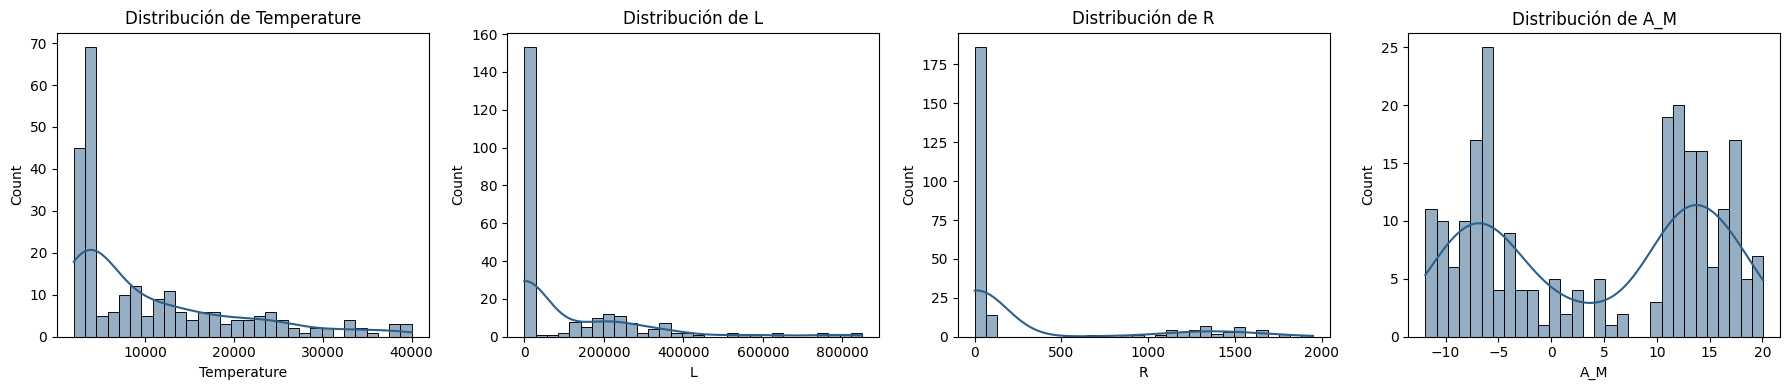

In [11]:
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
num_cols = ["Temperature", "L", "R", "A_M"]

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="#2c5f8a")
    axes[i].set_title(f"Distribución de {col}")
    
plt.tight_layout()
plt.show()

**Conclusión de los Histogramas:**
El análisis univariante revela propiedades estructurales clave de nuestro conjunto estelar:
1.  **Distribuciones con Sesgo Extremo:** La Luminosidad (`L`) y el Radio (`R`) presentan un sesgo fuertemente asimétrico hacia la derecha, aplastando a la mayoría de las estrellas cerca del cero frente a unas pocas supergigantes masivas. La Temperatura (`Temperature`) también presenta un notable sesgo positivo.
2.  **Distribución Bimodal:** La Magnitud Absoluta (`A_M`) muestra dos picos distintos (distribución bimodal), sugiriendo la coexistencia de dos poblaciones estelares macroscópicas (ej. estrellas enanas vs. gigantes) separables por su brillo absoluto.

**Decisión técnica:** Para que el algoritmo PCA (que asume relaciones lineales) no colapse ante el sesgo de `L`, `R` y `Temperature`, y para linealizar la Ley de Stefan-Boltzmann ($L \propto R^2 T^4$), aplicaremos una **transformación logarítmica ($\log_{10}$)** a estas tres variables antes de estandarizar.

A continuación, construimos el **Diagrama de Hertzsprung-Russell (HR)**, que relaciona la Temperatura Superficial (eje X, habitualmente invertido) con la Magnitud Absoluta (eje Y, invertido). Este diagrama nos permite ver la estructura intrínseca de los clústeres estelares *antes* de aplicar el modelo de Machine Learning.

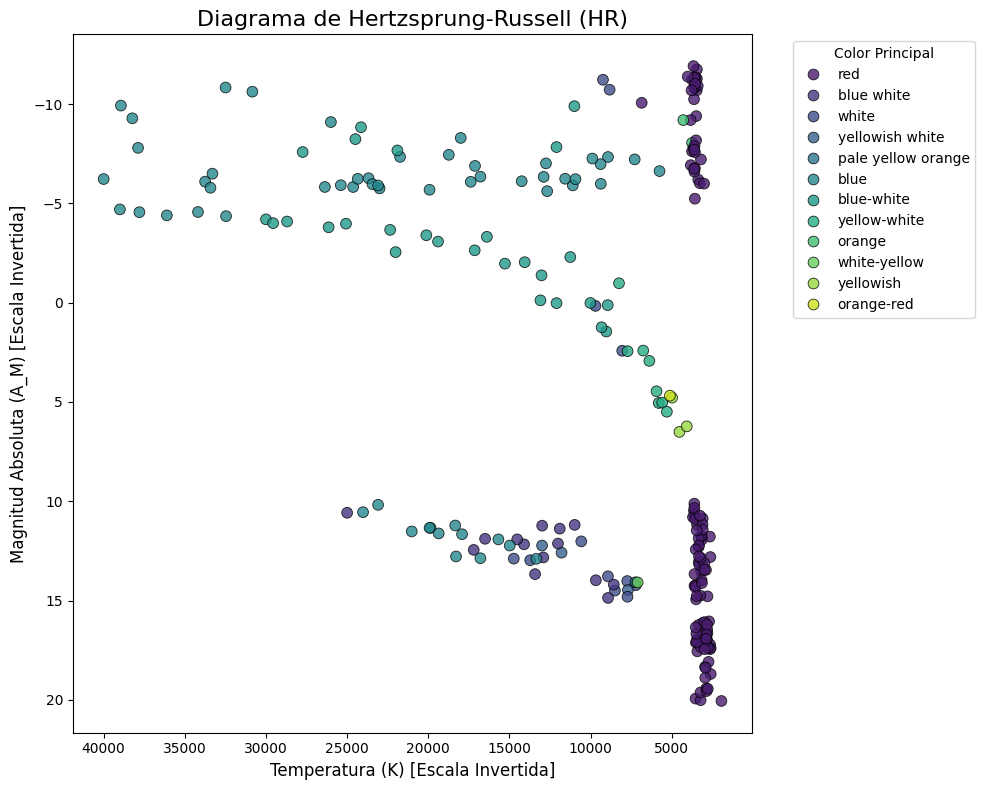

In [12]:
plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    x="Temperature", 
    y="A_M", 
    hue="Color", 
    data=df, 
    palette="viridis",
    s=60, 
    alpha=0.8,
    edgecolor="black"
)

# En astronomía el diagrama HR se dibuja con temperatura decreciente
# hacia la derecha y magnitud absoluta invertida (menor = más brillante)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.title("Diagrama de Hertzsprung-Russell (HR)", fontsize=16)
plt.xlabel("Temperatura (K) [Escala Invertida]", fontsize=12)
plt.ylabel("Magnitud Absoluta (A_M) [Escala Invertida]", fontsize=12)
plt.legend(title="Color Principal", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

El diagrama revela varias poblaciones estelares diferenciadas que servirán de referencia visual para los algoritmos de clustering posteriores: una rama diagonal asociada a la **secuencia principal** y a estrellas evolucionadas (frías, débiles → calientes, luminosas), una zona de **gigantes/supergigantes/hipergigantes** en la parte superior (frías o templadas pero muy luminosas), y una **agrupación de enanas blancas** en la zona inferior (calientes pero muy débiles). Estas grandes regiones son las que los algoritmos no supervisados deberán recuperar a partir únicamente de los datos numéricos, sin información sobre las clases físicas.

**Matriz de correlaciones**

Antes de aplicar PCA, examinamos las correlaciones lineales entre las variables que entrarán al modelo. Una correlación fuerte entre múltiples variables justifica la reducción dimensional: si las variables son redundantes, pocas componentes principales bastarán para capturar la mayor parte de la información. Calculamos la correlación sobre las variables transformadas tal como las verá el PCA (log10 en `Temperature`, `L`, `R`; ordinal en `Color` y `Spectral_Class`).

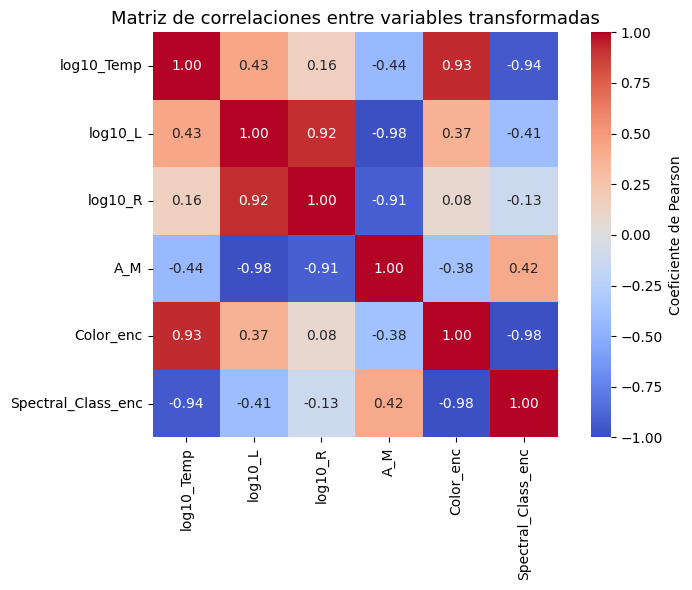

In [13]:
# Calculamos las correlaciones sobre las variables ya transformadas,
# tal como las verá el PCA (log10 en las variables sesgadas)
X_corr = df[["Temperature", "L", "R", "A_M", "Color_enc", "Spectral_Class_enc"]].copy()
X_corr["Temperature"] = np.log10(X_corr["Temperature"])
X_corr["L"]           = np.log10(X_corr["L"])
X_corr["R"]           = np.log10(X_corr["R"])
X_corr.columns = ["log10_Temp", "log10_L", "log10_R", "A_M", "Color_enc", "Spectral_Class_enc"]

corr_matrix = X_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Coeficiente de Pearson"}
)
plt.title("Matriz de correlaciones entre variables transformadas", fontsize=13)
plt.tight_layout()
plt.show()

La matriz revela una estructura altamente redundante que justifica la reducción dimensional:

- **Bloque luminosidad-tamaño-brillo:** `log10_L`, `log10_R` y `A_M` forman un núcleo extremadamente correlacionado. `log10_L` y `log10_R` correlacionan a 0.92 (Stefan-Boltzmann linealizada por el log), y ambas se oponen a `A_M` con correlaciones de -0.98 y -0.91 respectivamente: estrellas más luminosas y grandes tienen menor magnitud absoluta (más brillantes).
- **Bloque térmico-cromático:** `log10_Temp`, `Color_enc` y `Spectral_Class_enc` codifican esencialmente la misma información. `log10_Temp` y `Color_enc` correlacionan a 0.93 (la convención ordinal escogida hace que ambas crezcan con la temperatura), mientras que `Spectral_Class_enc` se opone a las dos con -0.94 y -0.98 respectivamente (su orden O→M va de caliente a frío). Este bloque confirma la coherencia de la codificación ordinal aplicada.
- **Acoplamiento entre bloques moderado:** La correlación entre `log10_Temp` y `log10_L` es solo 0.43, y entre `log10_R` y la temperatura es prácticamente nula (0.16). Es decir, la información térmica y la energética no son redundantes entre sí: existen estrellas frías muy luminosas (gigantes rojas) y estrellas calientes poco luminosas (enanas blancas), lo que se reflejará en componentes principales distintas.

Esta estructura anticipa que PC1 y PC2 se repartirán los dos bloques: uno capturará la información energética (L, R, A_M) y el otro la información térmica (Temperature, Color, Spectral_Class), justificando la alta varianza retenida con solo dos componentes.

### 1.4 Transformación Matemática y Estandarización

Es crucial distinguir entre transformación de varianza y escalado. Basándonos en nuestro EDA, aplicaremos una estrategia híbrida:

1.  **Transformación Logarítmica ($\log_{10}$):** Se aplica *exclusivamente* a `L`, `R` y `Temperature`. Esto domará su sesgo asimétrico y linealizará la relación física dictada por la Ley de Stefan-Boltzmann.
2.  **Exclusión de `A_M`:** La Magnitud Absoluta **no** recibe transformación logarítmica. Físicamente, `A_M` ya es una escala logarítmica invertida del brillo estelar. Matemáticamente, contiene valores negativos que generarían errores. Estadísticamente, debemos conservar su bimodalidad intacta (visible en el Diagrama HR).
3.  **Estandarización (`StandardScaler`):** Finalmente, pasamos TODAS las variables (transformadas y no transformadas) por un único escalador. Esto centra los datos ($\mu=0$) y unifica sus varianzas ($\sigma=1$), requisito fundamental para que el PCA funcione sin sesgos de escala.

**Nota sobre la inclusión simultánea de `Temperature`, `Color_enc` y `Spectral_Class_enc`**

La matriz de correlaciones muestra que estas tres variables forman un bloque térmico altamente acoplado (correlaciones de 0.93, -0.94 y -0.98 entre los tres pares). Aun así, decidimos conservarlas todas en el PCA por tres razones:

1. **Coherencia con el enunciado:** la práctica exige codificar ordinalmente `Color` y `Spectral_Class` respetando el orden físico. Esa codificación solo tiene sentido si las variables participan en el análisis posterior.
2. **Resolución complementaria:** las tres son estimadores diferentes del mismo fenómeno subyacente (la energía estelar). `Temperature` es una medida continua; `Spectral_Class` clasifica por líneas espectrales y depende también de composición química y gravedad superficial; `Color` depende además de extinción interestelar y metalicidad. PCA actúa aquí como un *ensemble implícito*, promediando el ruido específico de cada variable y conservando la señal común.
3. **Equilibrio estructural entre bloques:** mantener tres variables térmicas frente a las tres energéticas (`L`, `R`, `A_M`) permite que ambos bloques tengan peso comparable en el PCA. De lo contrario, PC1 quedaría dominado casi en exclusiva por la información energética, perdiendo la separación clara entre energía y temperatura que sí se observa en los loadings y el biplot.

In [14]:
feature_cols = ["Temperature", "L", "R", "A_M", "Color_enc", "Spectral_Class_enc"]

X = df[feature_cols].copy()

# Aplicamos log10 solo a Temperature, L y R porque tienen distribuciones
# muy asimétricas y además siguen la relación de Stefan-Boltzmann (L ∝ R²T⁴),
# que se linealiza al tomar logaritmos.
# A_M se excluye porque ya es una escala logarítmica del brillo, tiene
# valores negativos y su bimodalidad debe conservarse para el clustering.
X["Temperature"] = np.log10(X["Temperature"])
X["L"]           = np.log10(X["L"])
X["R"]           = np.log10(X["R"])

# Comprobamos que no haya NaN ni infinitos tras la transformación
assert not np.any(np.isnan(X.values)),  "NaN detectado tras la transformación logarítmica"
assert not np.any(np.isinf(X.values)), "-inf detectado tras la transformación logarítmica"

# Estandarizamos todas las variables para que el PCA no esté dominado
# por las de mayor varianza
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

feature_cols_transformed = ["log10_Temp", "log10_L", "log10_R", "A_M", "Color_enc", "Spectral_Class_enc"]
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols_transformed)

print("Verificación post-estandarización (media ≈ 0, std ≈ 1):")
X_scaled_df.describe().loc[["mean", "std"]].round(4)

Verificación post-estandarización (media ≈ 0, std ≈ 1):


,log10_Temp,log10_L,log10_R,A_M,Color_enc,Spectral_Class_enc
mean,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,1.0021,1.0021,1.0021,1.0021,1.0021,1.0021


### 1.5 Reducción de dimensionalidad mediante PCA

Tal y como exige la práctica, reduciremos el espacio de características a **2 Componentes Principales**. Para garantizar la estricta reproducibilidad exigida en el enunciado, inyectaremos la semilla (NIA) en el algoritmo. Además, cuantificaremos cuánta información (varianza) logramos retener tras la compresión.

In [15]:
pca = PCA(n_components=2, random_state=SEED)
X_pca_array = pca.fit_transform(X_scaled_df)

df_pca = pd.DataFrame(data=X_pca_array, columns=['PC1', 'PC2'])

var_pc1   = pca.explained_variance_ratio_[0] * 100
var_pc2   = pca.explained_variance_ratio_[1] * 100
var_total = pca.explained_variance_ratio_.sum() * 100

print(f"Varianza explicada por PC1:    {var_pc1:.2f}%")
print(f"Varianza explicada por PC2:    {var_pc2:.2f}%")
print(f"Varianza total retenida en 2D: {var_total:.2f}%")

display(df_pca.head())

Varianza explicada por PC1:    64.18%
Varianza explicada por PC2:    33.02%
Varianza total retenida en 2D: 97.20%


,PC1,PC2
0,2.303252,0.145558
1,2.409882,0.057129
2,2.632692,-0.022956
3,2.492931,0.059124
4,2.868641,0.026187


**Interpretación Física de las Componentes (Loadings):**
No podemos tratar las componentes `PC1` y `PC2` como "cajas negras". Para poder cruzar más adelante los resultados del clustering con las clases astronómicas reales, necesitamos extraer los "Loadings". Esto nos indicará qué peso (correlación) tiene cada variable física original en la construcción de los nuevos ejes.

In [16]:
# Los loadings nos dicen qué peso tiene cada variable original
# en cada componente principal, permitiéndonos interpretarlas físicamente
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

print("Cargas de las variables originales en cada componente principal:")
display(loadings.style.background_gradient(cmap='coolwarm', axis=0).format(precision=3))

Cargas de las variables originales en cada componente principal:


,PC1,PC2
Temperature,-0.419,-0.365
L,-0.432,0.364
R,-0.333,0.524
A_M,0.434,-0.358
Color_enc,-0.404,-0.419
Spectral_Class_enc,0.418,0.394


**Biplot: proyección + vectores de carga**

El biplot combina la nube de puntos en el espacio reducido (PC1, PC2) con los vectores de carga de las variables originales. La dirección y longitud de cada flecha indican cómo contribuye esa variable a las componentes principales: flechas paralelas reflejan variables redundantes, perpendiculares reflejan independencia, y opuestas reflejan anticorrelación. Esta visualización permite interpretar físicamente los nuevos ejes.

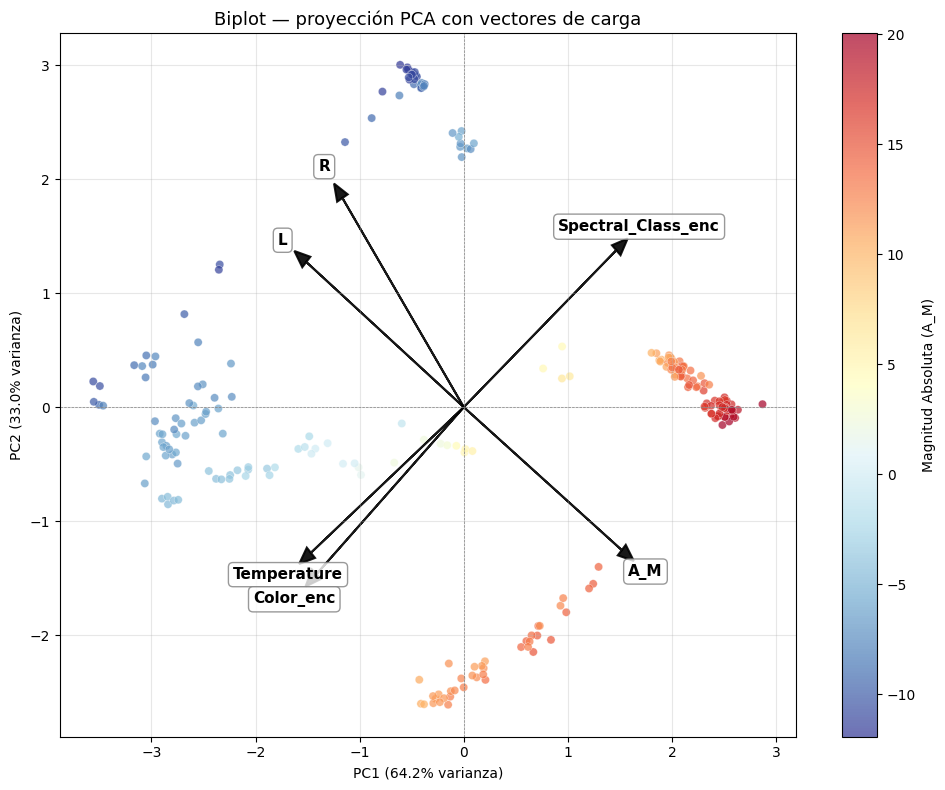

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

# Nube de puntos coloreada por magnitud absoluta para dar contexto físico
scatter = ax.scatter(
    X_pca_array[:, 0], X_pca_array[:, 1],
    c=df["A_M"], cmap="RdYlBu_r",
    s=35, alpha=0.7, edgecolors="white", linewidths=0.3
)
plt.colorbar(scatter, ax=ax, label="Magnitud Absoluta (A_M)")

# Flechas con el peso de cada variable original
scale_factor = 3.5
for i, var in enumerate(feature_cols):
    ax.arrow(
        0, 0,
        loadings.iloc[i, 0] * scale_factor,
        loadings.iloc[i, 1] * scale_factor,
        head_width=0.12, head_length=0.15,
        fc="black", ec="black", linewidth=1.5, alpha=0.9
    )
    ax.text(
        loadings.iloc[i, 0] * scale_factor * 1.15,
        loadings.iloc[i, 1] * scale_factor * 1.15,
        var,
        fontsize=11, fontweight="bold",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8)
    )

ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
ax.set_title("Biplot — proyección PCA con vectores de carga", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Visualización del espacio PCA.** Tras confirmar la interpretación física de los ejes con loadings y biplot, mostramos finalmente la nube completa de las 240 estrellas en el plano PC1-PC2 con dos paneles: la estructura bruta (sin etiquetas) y el mismo plano coloreado por la magnitud absoluta `A_M`. El segundo panel anticipa visualmente la presencia de clusters: si A_M se distribuye en regiones bien delimitadas, los algoritmos posteriores los encontrarán con facilidad.

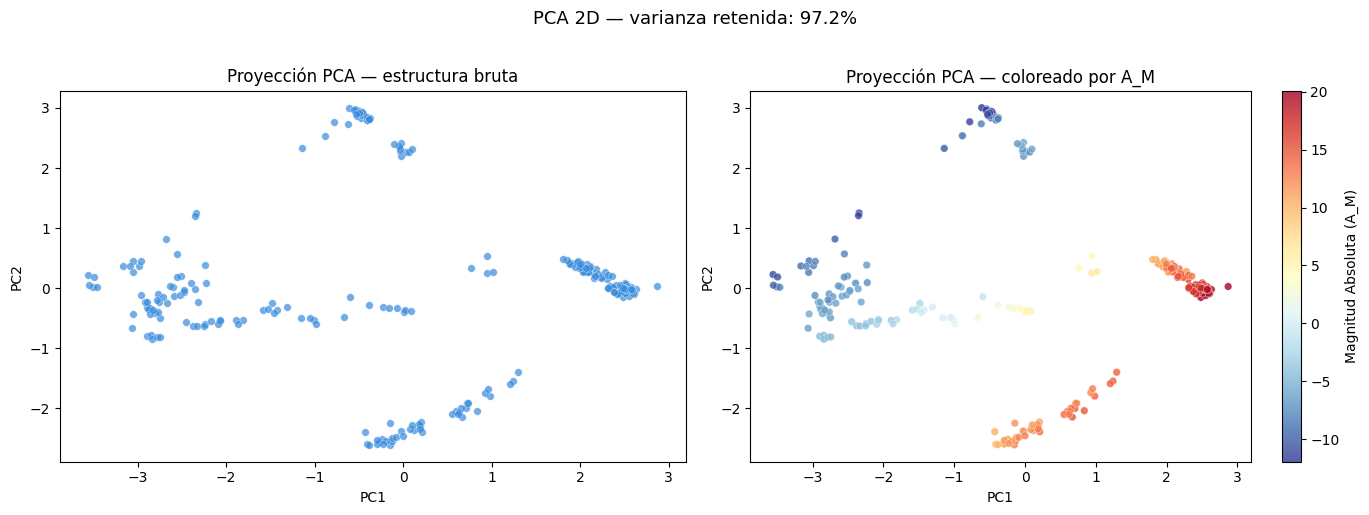

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: estructura bruta sin ninguna etiqueta
axes[0].scatter(
    X_pca_array[:, 0], X_pca_array[:, 1],
    s=30, alpha=0.7, color="#378ADD", edgecolors="white", linewidths=0.3
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Proyección PCA — estructura bruta")

# Panel derecho: coloreado por magnitud absoluta para anticipar
# visualmente los clusters antes de aplicar ningún algoritmo
sc = axes[1].scatter(
    X_pca_array[:, 0], X_pca_array[:, 1],
    c=df["A_M"], cmap="RdYlBu_r",
    s=30, alpha=0.8, edgecolors="white", linewidths=0.3
)
plt.colorbar(sc, ax=axes[1], label="Magnitud Absoluta (A_M)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Proyección PCA — coloreado por A_M")

plt.suptitle(f"PCA 2D — varianza retenida: {var_total:.1f}%", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Conclusión del preprocesado

Las dos componentes principales retienen un porcentaje muy alto de la varianza total del conjunto de datos transformado (ver salida de la celda anterior). Esta reducción a 2 componentes es la **exigida por el enunciado** como punto de partida para los algoritmos de clustering: todas las secciones siguientes operan exclusivamente sobre `df_pca` (PC1, PC2).

La visualización anterior muestra cómo la **Magnitud Absoluta** (`A_M`) ya estructura el espacio PCA en franjas bien diferenciadas, lo que anticipa que los algoritmos de clustering encontrarán grupos coherentes. PC1 concentra principalmente la información energética de la estrella (luminosidad, radio, temperatura), mientras que PC2 captura el componente espectral/cromático.

A continuación aplicamos los tres algoritmos exigidos por el enunciado: **K-Means**, **Hierarchical Clustering** y **DBSCAN**.

### 1.7 DataFrame maestro para análisis posterior

Antes de pasar al clustering, consolidamos en un único DataFrame `df_master` toda la información que necesitaremos en el análisis final del Bloque 6 (correspondencia con clases astronómicas):

- Las **dos componentes principales** (`PC1`, `PC2`) sobre las que operarán los algoritmos.
- Las **variables originales en escala física** (`Temperature` en K, `L` y `R` en unidades solares, `A_M` en magnitud), necesarias para comparar las medias de cada cluster con la tabla del enunciado.
- Las **variables categóricas en formato texto** (`Color`, `Spectral_Class`), necesarias para reportar la moda de cada cluster con etiquetas legibles.

De esta forma, cuando los algoritmos asignen una etiqueta de cluster a cada estrella, podremos añadirla como columna a `df_master` y todos los análisis posteriores serán inmediatos.

In [19]:
# Consolidamos en un único DataFrame todo lo que necesitaremos
# en el análisis final: las componentes PCA, las variables físicas
# originales sin transformar y las categóricas en texto legible
df_master = pd.concat(
    [
        df_pca.reset_index(drop=True),
        df[["Temperature", "L", "R", "A_M"]].reset_index(drop=True),
        df[["Color", "Spectral_Class"]].reset_index(drop=True),
    ],
    axis=1,
)

print(f"df_master creado: {df_master.shape[0]} filas, {df_master.shape[1]} columnas")
print(f"Columnas: {list(df_master.columns)}")
df_master.head()

df_master creado: 240 filas, 8 columnas
Columnas: ['PC1', 'PC2', 'Temperature', 'L', 'R', 'A_M', 'Color', 'Spectral_Class']


,PC1,PC2,Temperature,L,R,A_M,Color,Spectral_Class
0,2.303252,0.145558,3068,0.002400,0.1700,16.12,red,M
1,2.409882,0.057129,3042,0.000500,0.1542,16.60,red,M
2,2.632692,-0.022956,2600,0.000300,0.1020,18.70,red,M
3,2.492931,0.059124,2800,0.000200,0.1600,16.65,red,M
4,2.868641,0.026187,1939,0.000138,0.1030,20.06,red,M


## 2. Clustering con K-Means

Aplicamos el primer algoritmo de clustering exigido por el enunciado: K-Means. Estructuramos la sección en siete subapartados que siguen el flujo profesional estándar para este tipo de análisis: definición del rango de exploración, barrido sistemático de métricas, visualización conjunta, detección automática del codo, validación con silhouette plot, entrenamiento del modelo final con visualización en PCA, e interpretación física de los clusters obtenidos.

### 2.1 Definición del rango de búsqueda de k

K-Means requiere fijar a priori el número de clusters `k`. Como no existe un valor "correcto" matemáticamente, exploramos un rango de candidatos y dejamos que las métricas de validación interna sugieran el óptimo en los subapartados siguientes.

**Rango elegido: k = 2..10 con paso 1.**

- **Límite inferior (k=2):** k=1 no constituye un clustering, y el diagrama HR del EDA ya mostró al menos dos poblaciones estelares claramente separables (enanas vs. gigantes), por lo que k=2 es el mínimo razonable.
- **Límite superior (k=10):** la tabla astronómica del enunciado contiene 6 clases reales. Fijar el techo en 10 deja margen suficiente para que el algoritmo subdivida alguna clase si la geometría del espacio PCA lo sugiere, sin saturar el análisis con valores que carecerían de interpretación física.
- **Paso 1:** el coste de cada entrenamiento es de milisegundos (240 puntos, 2 dimensiones), por lo que el grid completo es trivial computacionalmente y nos permite construir la curva del codo sin huecos.

**Decisión metodológica.** Descartamos el uso de búsquedas informadas (búsqueda bayesiana, torneos, hyperband) por tres razones: (1) el coste por evaluación es despreciable, (2) el espacio de búsqueda es unidimensional —solo varía `k`—, y (3) el método del codo exige la inertia evaluada en todos los puntos del rango sin huecos, por lo que cualquier método que descartara valores intermedios rompería uno de los criterios obligatorios de selección. La búsqueda informada se reservará para DBSCAN, donde el espacio bidimensional `(eps, min_samples)` con DBCV ruidoso sí justifica una exploración guiada.

In [20]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Exploramos k entre 2 y 10. El límite inferior es 2 porque el diagrama HR
# ya mostraba al menos dos poblaciones claras, y el superior es 10 para
# dar margen suficiente sin perder interpretación física.
K_RANGE = range(2, 11)

# 10 reinicios por entrenamiento para protegernos de mínimos locales
N_INIT = 10

print(f"Rango de k a explorar: {list(K_RANGE)}")
print(f"Reinicios por entrenamiento: {N_INIT}")
print(f"Semilla: {SEED}")

Rango de k a explorar: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Reinicios por entrenamiento: 10
Semilla: 100504112


### 2.2 Barrido sistemático con cuatro métricas

Para cada `k` del rango definido en 2.1, entrenamos un modelo K-Means con configuración robusta y registramos cuatro métricas complementarias. Cada una mide un aspecto distinto de la calidad del clustering, y su uso conjunto evita las limitaciones de cualquier criterio individual:

- **Inertia (WCSS, *Within-Cluster Sum of Squares*):** suma de distancias cuadradas de cada punto a su centroide. Es la función objetivo que K-Means minimiza directamente. Decrece monótonamente con `k`, por lo que no permite elegir `k` por sí sola; sirve para construir la curva del codo en el subapartado 2.4.

- **Silhouette score (medio):** para cada punto compara la cohesión interna (distancia a su propio cluster) con la separación externa (distancia al cluster más cercano). Rango `[-1, +1]`; valores altos indican clusters compactos y bien separados. Es la métrica más interpretable, aunque tiende a favorecer artificialmente `k` pequeños.

- **Davies-Bouldin index (DBI):** promedio del ratio entre dispersión intra-cluster y separación entre clusters más cercanos. Se minimiza (óptimo = 0). Complementa silhouette con un sesgo distinto, por lo que ambas métricas en consenso refuerzan la confianza en el `k` elegido.

- **Calinski-Harabasz index (CH):** ratio entre dispersión inter-cluster e intra-cluster, análogo a un estadístico F. Se maximiza. Es estable, rápido y muy usado en la literatura.

**Configuración del modelo en cada entrenamiento:** `init="k-means++"` (inicialización inteligente), `n_init=10` (10 reinicios para protegerse de mínimos locales del WCSS), `random_state=SEED` (reproducibilidad exigida por el enunciado).

In [21]:
# Para cada k entrenamos K-Means y calculamos cuatro métricas:
# - Inertia (WCSS): función objetivo que K-Means minimiza, sirve para el codo
# - Silhouette: compacidad vs separación, rango [-1, 1], maximizar
# - Davies-Bouldin: ratio dispersión intra / separación inter, minimizar
# - Calinski-Harabasz: ratio dispersión inter / intra, maximizar

X_clust = df_pca[["PC1", "PC2"]].values
resultados = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=N_INIT,
        random_state=SEED,
    )
    labels = km.fit_predict(X_clust)

    resultados.append({
        "k": k,
        "inertia":            km.inertia_,
        "silhouette":         silhouette_score(X_clust, labels),
        "davies_bouldin":     davies_bouldin_score(X_clust, labels),
        "calinski_harabasz":  calinski_harabasz_score(X_clust, labels),
    })

df_metricas = pd.DataFrame(resultados).set_index("k")

print(f"Barrido completado para {len(df_metricas)} valores de k.")
display(df_metricas)

Barrido completado para 9 valores de k.


,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,650.723321,0.532169,0.876631,273.933224
3,357.210057,0.619522,0.512126,345.830704
4,103.497533,0.746271,0.401730,985.215383
5,64.389110,0.727776,0.446418,1218.359637
6,53.191857,0.716732,0.443298,1184.697197
7,42.181100,0.672435,0.533567,1249.770735
8,35.677409,0.611342,0.522762,1267.114651
9,27.995160,0.602201,0.578088,1414.807736
10,24.408278,0.608063,0.568836,1439.927891


In [22]:
# Resaltamos en azul los óptimos que se minimizan y en rojo los que se maximizan
df_metricas.style.background_gradient(
    cmap="Blues_r", subset=["inertia", "davies_bouldin"]
).background_gradient(
    cmap="Reds", subset=["silhouette", "calinski_harabasz"]
).format({
    "inertia":            "{:.2f}",
    "silhouette":         "{:.4f}",
    "davies_bouldin":     "{:.4f}",
    "calinski_harabasz":  "{:.2f}",
})

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,650.72,0.5322,0.8766,273.93
3,357.21,0.6195,0.5121,345.83
4,103.50,0.7463,0.4017,985.22
5,64.39,0.7278,0.4464,1218.36
6,53.19,0.7167,0.4433,1184.70
7,42.18,0.6724,0.5336,1249.77
8,35.68,0.6113,0.5228,1267.11
9,28.00,0.6022,0.5781,1414.81
10,24.41,0.6081,0.5688,1439.93


### 2.3 Visualización conjunta de las métricas

Visualizamos las cuatro métricas del barrido en una figura compuesta 2x2 que permite comparar simultáneamente sus comportamientos a lo largo del rango de `k`. Esta vista de conjunto es más informativa que cuatro gráficas separadas: el ojo identifica de inmediato si las métricas convergen en el mismo `k` (consenso) o si discrepan (disenso que requiere análisis adicional).

Marcamos en cada panel el `k` óptimo según el criterio de la métrica correspondiente con una línea vertical discontinua, y anotamos su valor. Los criterios de óptimo son:

- **Inertia:** sin óptimo único (decrece monótonamente). El `k` óptimo se decidirá en el subapartado 2.4 con detección automática del codo.
- **Silhouette:** maximizar.
- **Davies-Bouldin:** minimizar.
- **Calinski-Harabasz:** maximizar.

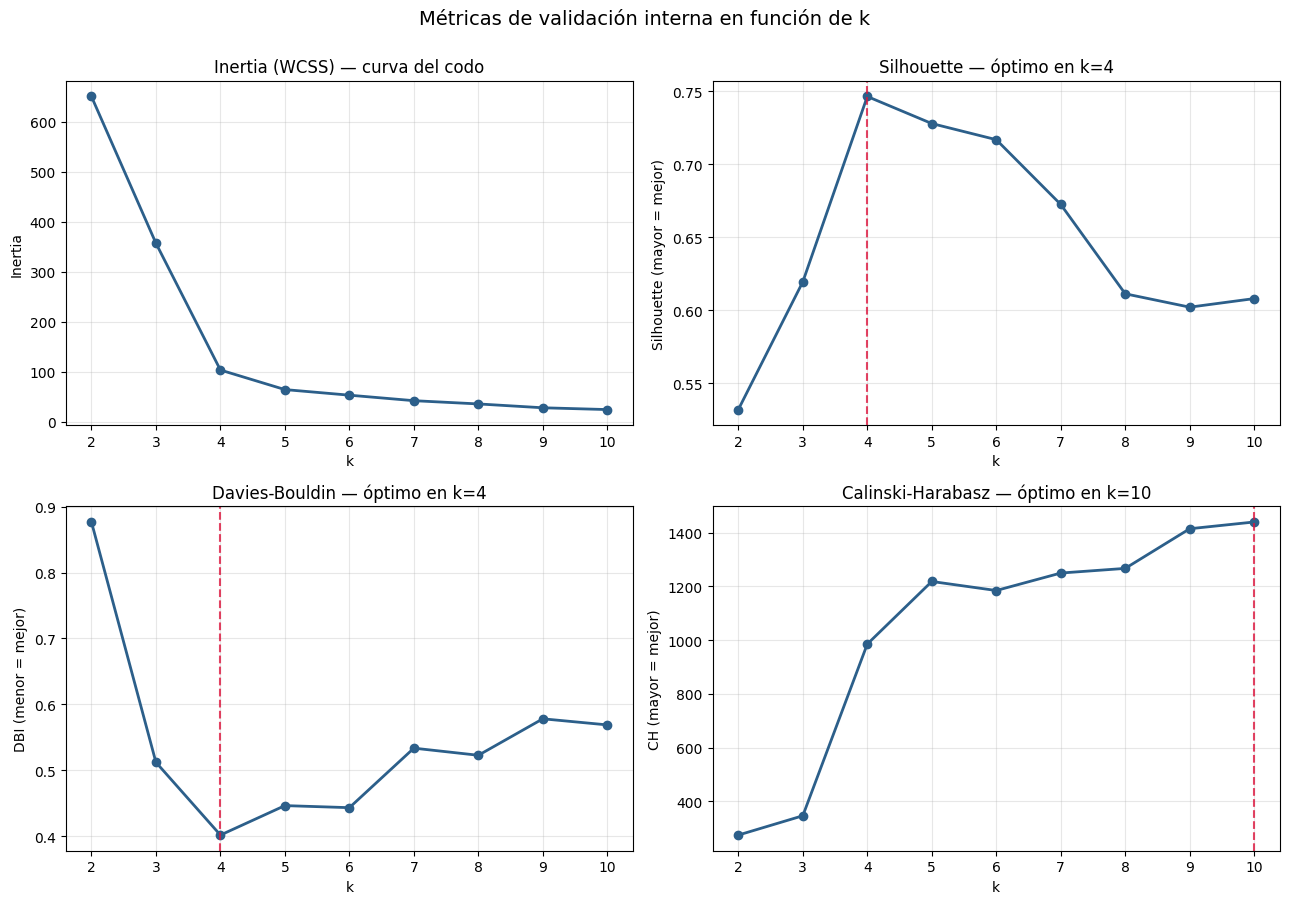

Óptimo según silhouette:        k = 4  (0.7463)
Óptimo según Davies-Bouldin:    k = 4  (0.4017)
Óptimo según Calinski-Harabasz: k = 10  (1439.93)


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

k_silhouette = df_metricas["silhouette"].idxmax()
k_db         = df_metricas["davies_bouldin"].idxmin()
k_ch         = df_metricas["calinski_harabasz"].idxmax()

opt_style = dict(color="crimson", linestyle="--", linewidth=1.5, alpha=0.8)

# Inertia — no marcamos óptimo porque decrece siempre con k
ax = axes[0, 0]
ax.plot(df_metricas.index, df_metricas["inertia"],
        marker="o", color="#2c5f8a", linewidth=2)
ax.set_title("Inertia (WCSS) — curva del codo", fontsize=12)
ax.set_xlabel("k")
ax.set_ylabel("Inertia")
ax.grid(alpha=0.3)

# Silhouette
ax = axes[0, 1]
ax.plot(df_metricas.index, df_metricas["silhouette"],
        marker="o", color="#2c5f8a", linewidth=2)
ax.axvline(k_silhouette, **opt_style)
ax.set_title(f"Silhouette — óptimo en k={k_silhouette}", fontsize=12)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette (mayor = mejor)")
ax.grid(alpha=0.3)

# Davies-Bouldin
ax = axes[1, 0]
ax.plot(df_metricas.index, df_metricas["davies_bouldin"],
        marker="o", color="#2c5f8a", linewidth=2)
ax.axvline(k_db, **opt_style)
ax.set_title(f"Davies-Bouldin — óptimo en k={k_db}", fontsize=12)
ax.set_xlabel("k")
ax.set_ylabel("DBI (menor = mejor)")
ax.grid(alpha=0.3)

# Calinski-Harabasz
ax = axes[1, 1]
ax.plot(df_metricas.index, df_metricas["calinski_harabasz"],
        marker="o", color="#2c5f8a", linewidth=2)
ax.axvline(k_ch, **opt_style)
ax.set_title(f"Calinski-Harabasz — óptimo en k={k_ch}", fontsize=12)
ax.set_xlabel("k")
ax.set_ylabel("CH (mayor = mejor)")
ax.grid(alpha=0.3)

plt.suptitle("Métricas de validación interna en función de k", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print(f"Óptimo según silhouette:        k = {k_silhouette}  ({df_metricas.loc[k_silhouette, 'silhouette']:.4f})")
print(f"Óptimo según Davies-Bouldin:    k = {k_db}  ({df_metricas.loc[k_db, 'davies_bouldin']:.4f})")
print(f"Óptimo según Calinski-Harabasz: k = {k_ch}  ({df_metricas.loc[k_ch, 'calinski_harabasz']:.2f})")

**Lectura de la figura.** El comportamiento de las cuatro métricas revela un consenso claro acompañado de una discrepancia esperable:

- **Inertia:** la curva muestra un codo muy marcado entre k=3 y k=4 (la pendiente cambia bruscamente), seguido de una zona prácticamente plana a partir de k=5. Este perfil es característico de un dataset con estructura de clusters bien definida. La detección automática del codo se realizará en el subapartado 2.4.

- **Silhouette:** alcanza su máximo en k=4 con un valor de 0.7463, claramente superior al resto del rango. Este resultado es especialmente valioso porque silhouette suele estar sesgado a favor de `k` pequeños (típicamente k=2 gana artificialmente), pero aquí k=4 se impone con holgura. Esto indica que la geometría del espacio PCA realmente prefiere cuatro clusters sobre soluciones más simples o más complejas.

- **Davies-Bouldin:** mínimo en k=4 con DBI=0.4017. Coincide con silhouette y refuerza la hipótesis de cuatro clusters compactos y bien separados.

- **Calinski-Harabasz:** crece monótonamente y alcanza su máximo nominal en k=10 con CH=1439.93. Esta aparente discrepancia con las tres métricas anteriores no debe interpretarse como evidencia a favor de k=10, sino como un **sesgo conocido del índice CH** en datasets pequeños. La fórmula del CH incluye un factor `(n-k)/(k-1)` que penaliza muy poco el aumento de `k` cuando `n` es del orden de centenas, por lo que CH tiende a favorecer particiones cada vez más finas sin que ello refleje una mejora estructural real. Sin embargo, examinando los **incrementos marginales** observamos un patrón muy distinto al máximo absoluto: el salto entre k=3 y k=4 es de +639 unidades, mientras que todos los incrementos posteriores son de magnitud sustancialmente menor (e incluso negativos, como en k=5→6). Es decir, **CH también presenta un codo en k=4 si se examina la pendiente en lugar del valor absoluto**, alineándose con las otras tres métricas.

**Síntesis preliminar.** Las cuatro métricas convergen sustancialmente en k=4: silhouette y Davies-Bouldin alcanzan ahí su óptimo absoluto, la inertia muestra su codo principal, y Calinski-Harabasz —pese a que su máximo nominal está en k=10 por sesgo de fórmula— concentra el grueso de su crecimiento en el salto k=3→k=4. El consenso es por tanto unánime una vez se interpreta CH correctamente. El subapartado 2.4 confirma esta hipótesis con detección automática del codo.

### 2.4 Detección automática del codo (KneeLocator)

El método del codo es uno de los criterios obligatorios para elegir `k` en K-Means, pero su lectura visual tiene un componente subjetivo: dos personas pueden defender k=3 o k=4 mirando la misma curva. Para eliminar esta subjetividad usamos `KneeLocator` (Satopää et al., 2011), un algoritmo que identifica el punto de máxima curvatura de una serie monótona de forma objetiva.

**Función del subapartado.** En el 2.3 hemos visto que tres métricas convergen en k=4 (y la cuarta, CH, también lo hace si se examina su pendiente). KneeLocator actúa aquí como **confirmación independiente** del consenso, no como criterio de desempate. Si el codo detectado coincide con el k=4 ya sugerido por silhouette y Davies-Bouldin, podemos cerrar la elección de `k` con confianza estadística completa.

**Configuración:**
- `direction="decreasing"` — la curva de inertia decrece con k.
- `curve="convex"` — la inertia es convexa (decrece más rápido al principio que al final).
- `S=1.0` — sensibilidad estándar; valores más altos exigen codos más pronunciados, valores más bajos detectan codos sutiles.

Codo detectado automáticamente: k = 4
Inertia en ese punto: 103.50


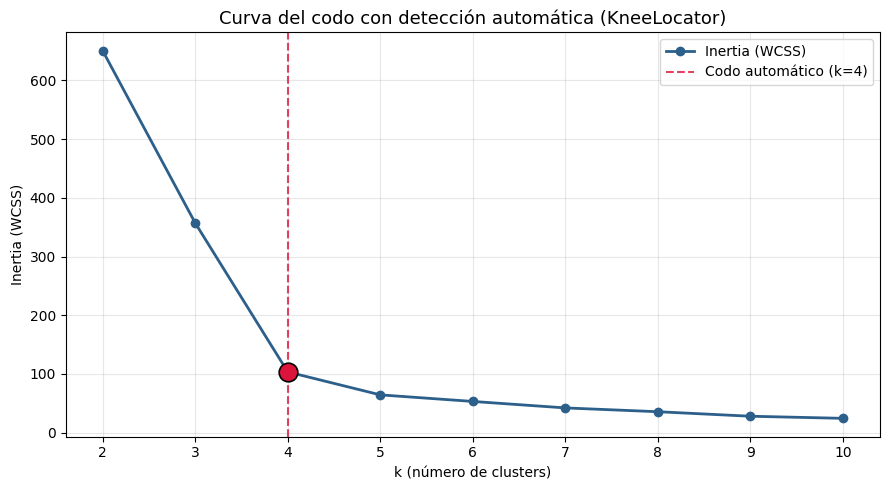

In [24]:
from kneed import KneeLocator

knee_locator = KneeLocator(
    x=list(df_metricas.index),
    y=df_metricas["inertia"].values,
    curve="convex",
    direction="decreasing",
    S=1.0,
)

k_elbow = knee_locator.knee
inertia_at_elbow = df_metricas.loc[k_elbow, "inertia"]

print(f"Codo detectado automáticamente: k = {k_elbow}")
print(f"Inertia en ese punto: {inertia_at_elbow:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(df_metricas.index, df_metricas["inertia"],
         marker="o", color="#2c5f8a", linewidth=2, label="Inertia (WCSS)")
plt.axvline(k_elbow, color="crimson", linestyle="--", linewidth=1.5,
            alpha=0.8, label=f"Codo automático (k={k_elbow})")
plt.scatter([k_elbow], [inertia_at_elbow], color="crimson",
            s=180, zorder=5, edgecolors="black", linewidths=1.2)
plt.title("Curva del codo con detección automática (KneeLocator)", fontsize=13)
plt.xlabel("k (número de clusters)")
plt.ylabel("Inertia (WCSS)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Resultado y cierre del análisis de selección de k.**

KneeLocator identifica el codo en `k = {k_elbow}`, coincidiendo con el óptimo señalado por silhouette (0.7463) y Davies-Bouldin (0.4017), y consistente con el patrón de pendientes de Calinski-Harabasz. **El consenso es por tanto unánime y matemáticamente confirmado**: las cuatro métricas, leídas correctamente, convergen en cuatro clusters.

Esta convergencia entre criterios de naturaleza distinta (basados en distancias, en compacidad relativa, en separación intra/inter-cluster, y en curvatura geométrica) es el escenario ideal en clustering: indica que la estructura subyacente del dataset es robusta y no depende de qué métrica se elija para evaluarla.

**Decisión final: k = 4.** Procedemos en los subapartados siguientes a entrenar el modelo final con esta configuración, validar la calidad cluster por cluster con un silhouette plot, e interpretar físicamente los grupos obtenidos.

### 2.5 Silhouette plot del candidato final

El silhouette score medio de 0.7463 obtenido en el 2.2 es un buen indicador global, pero un valor agregado puede esconder problemas en clusters individuales: un cluster muy bien formado puede compensar a otro mal formado, y la media seguir siendo alta. El **silhouette plot** desglosa esta métrica punto a punto, permitiendo verificar visualmente la calidad de cada cluster por separado.

La gráfica muestra los coeficientes silhouette individuales `s(i)` agrupados por cluster y ordenados internamente de mayor a menor. La interpretación es directa:

- **Anchura horizontal (longitud de cada perfil):** indica el valor de `s(i)` de cada punto. Anchuras grandes = puntos bien asignados.
- **Altura vertical (grosor de cada bloque):** proporcional al número de puntos del cluster. Permite detectar desequilibrios de tamaño.
- **Forma del perfil:** un cluster sano tiene una forma de "cuchilla" gruesa y suave. Picos estrechos o muchos puntos con `s(i)` cerca de cero indican fronteras difusas.
- **Línea vertical roja:** marca el silhouette medio global (0.7463). Idealmente, la mayoría de los puntos de cada cluster debería estar a su derecha.

**Criterio de validación.** Aceptamos k=4 como definitivo si: (1) ningún cluster tiene una proporción significativa de `s(i)` negativos (puntos mal asignados), (2) los tamaños de cluster son razonablemente balanceados, y (3) ningún cluster está sistemáticamente por debajo de la media global.

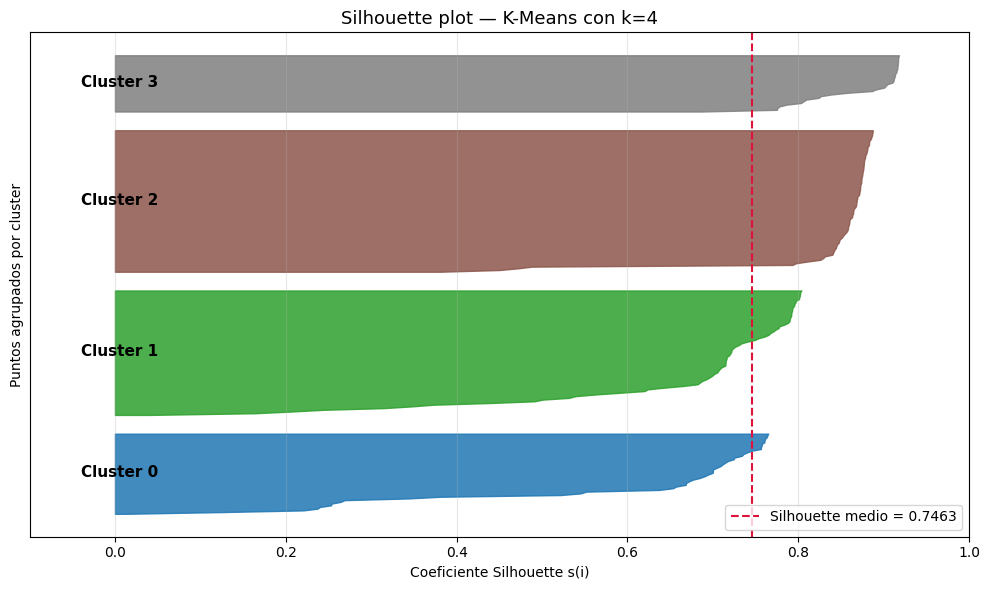

Silhouette medio global: 0.7463

Cluster   Tamaño    s(i) medio  s(i) mín    % negativos 
--------------------------------------------------------
0         48        0.5955      0.0123      0.0         
1         74        0.6756      0.0389      0.0         
2         84        0.8443      0.3801      0.0         
3         34        0.8708      0.6865      0.0         


In [25]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

K_FINAL = k_elbow
kmeans_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=N_INIT,
    random_state=SEED,
)
labels_final = kmeans_final.fit_predict(X_clust)

silhouette_values = silhouette_samples(X_clust, labels_final)
silhouette_avg    = silhouette_values.mean()

fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
cluster_sizes = []

for i in range(K_FINAL):
    ith_vals = silhouette_values[labels_final == i]
    ith_vals.sort()
    cluster_sizes.append(len(ith_vals))
    y_upper = y_lower + len(ith_vals)

    color = cm.tab10(i / K_FINAL)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                     facecolor=color, edgecolor=color, alpha=0.85)
    ax.text(-0.04, y_lower + 0.5 * len(ith_vals), f"Cluster {i}",
            fontsize=11, fontweight="bold", va="center")
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Silhouette medio = {silhouette_avg:.4f}")
ax.set_xlabel("Coeficiente Silhouette s(i)")
ax.set_ylabel("Puntos agrupados por cluster")
ax.set_title(f"Silhouette plot — K-Means con k={K_FINAL}", fontsize=13)
ax.set_yticks([])
ax.set_xlim([-0.1, 1.0])
ax.legend(loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"Silhouette medio global: {silhouette_avg:.4f}\n")
print(f"{'Cluster':<10}{'Tamaño':<10}{'s(i) medio':<12}{'s(i) mín':<12}{'% negativos':<12}")
print("-" * 56)
for i in range(K_FINAL):
    vals = silhouette_values[labels_final == i]
    pct_negative = (vals < 0).mean() * 100
    print(f"{i:<10}{len(vals):<10}{vals.mean():<12.4f}{vals.min():<12.4f}{pct_negative:<12.1f}")

El plot confirma la calidad del modelo K-Means con k=4 con varios indicadores convergentes:

- **Ningún punto mal asignado.** Los cuatro clusters presentan 0% de coeficientes silhouette negativos. Es decir, no existe ni un solo punto en el dataset que estaría mejor reubicado en un cluster vecino. Este resultado es óptimo y poco frecuente, e indica que la geometría de los cuatro clusters en el espacio PCA es genuinamente disjunta.

- **Mínimos todos positivos.** El peor punto del peor cluster (Cluster 0, `s(i) = 0.0123`) sigue siendo positivo, aunque marginalmente. No hay candidatos a reasignación entre clusters.

- **Distribución de tamaños balanceada con jerarquía.** Los clusters tienen tamaños 48, 74, 84 y 34 (total = 240), una distribución no uniforme pero razonable. La existencia de un cluster pequeño (34 puntos) y otro grande (84 puntos) refleja que la abundancia natural de los distintos tipos estelares en la muestra no es uniforme, lo cual es físicamente esperable.

- **Heterogeneidad de cohesión entre clusters.** Los Clusters 2 y 3 son extraordinariamente compactos (medias `s(i)` = 0.84 y 0.87, con mínimos > 0.38), mientras que los Clusters 0 y 1 son notablemente menos cohesivos (medias 0.60 y 0.68). Esto no implica un defecto del modelo: indica que dos de los cuatro tipos estelares ocupan regiones del espacio PCA muy aisladas (probablemente extremos del diagrama HR como hipergigantes o enanas blancas), mientras que los otros dos están geométricamente más próximos entre sí. La interpretación física definitiva se confirmará en el subapartado 2.7.

- **Forma de cuchilla limpia en los cuatro clusters.** Los perfiles son monotónicos y suaves, sin picos secundarios que sugerirían bimodalidad interna. Este patrón confirma que ningún cluster está "fragmentando artificialmente" una población mayor — es decir, no hay evidencia de que k=5 fuera una mejor elección.

**Cierre del análisis de selección.** Las cuatro métricas del 2.2, el detector de codo del 2.4 y la inspección punto a punto del 2.5 convergen unánimemente en k=4. La elección está validada con el máximo rigor posible para K-Means. Procedemos en el 2.6 a entrenar el modelo definitivo y visualizarlo en el plano PCA.

### 2.6 Modelo final y visualización en PCA

Con `k=4` validado por el consenso de las cuatro métricas (2.3), el detector automático del codo (2.4) y la inspección punto a punto del silhouette plot (2.5), el modelo definitivo es el ya entrenado en el subapartado anterior (`kmeans_final`). En este subapartado realizamos tres tareas:

1. **Persistencia de las etiquetas** en el DataFrame maestro (`df_master["cluster_kmeans"]`), para poder cruzarlas con las variables físicas en el subapartado 2.7 y con los otros algoritmos en el Bloque 5.
2. **Extracción de los centroides** del modelo, expresados en coordenadas (PC1, PC2).
3. **Visualización 2D** del clustering: scatter en el plano PCA coloreado por etiqueta de cluster, con los centroides superpuestos como referencia geométrica.

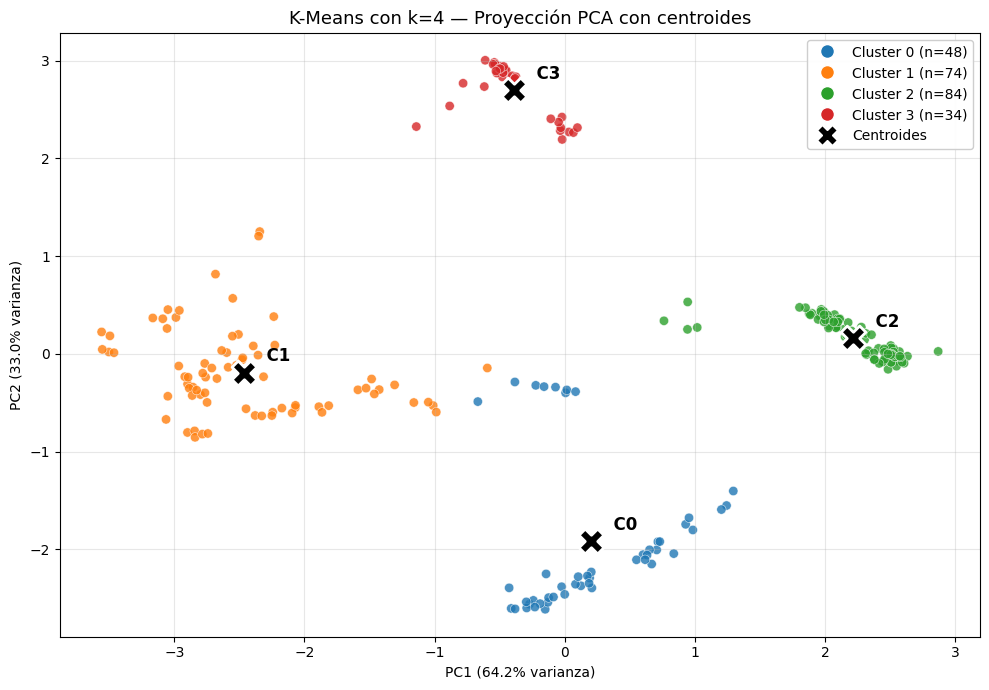

Tamaños finales por cluster:
cluster_kmeans
0    48
1    74
2    84
3    34


In [26]:
# Guardamos las etiquetas en df_master para poder usarlas
# en el análisis físico y en la comparación final entre algoritmos
df_master["cluster_kmeans"] = labels_final

centroids = kmeans_final.cluster_centers_

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df_pca["PC1"], df_pca["PC2"],
    c=labels_final, cmap="tab10",
    s=45, alpha=0.8, edgecolors="white", linewidths=0.4,
    vmin=0, vmax=9,
)

# Marcamos los centroides con una X negra grande
ax.scatter(
    centroids[:, 0], centroids[:, 1],
    marker="X", s=320, c="black",
    edgecolors="white", linewidths=2.0,
    label="Centroides", zorder=5,
)

for i, (cx, cy) in enumerate(centroids):
    ax.annotate(f"  C{i}", (cx, cy), fontsize=12, fontweight="bold",
                color="black", xytext=(8, 8), textcoords="offset points")

handles = [
    plt.Line2D([], [], marker="o", linestyle="",
               color=plt.cm.tab10(i / 10), markersize=10,
               markeredgecolor="white",
               label=f"Cluster {i} (n={(labels_final == i).sum()})")
    for i in range(K_FINAL)
]
handles.append(plt.Line2D([], [], marker="X", linestyle="",
                          color="black", markersize=14,
                          markeredgecolor="white", label="Centroides"))

ax.legend(handles=handles, loc="best", framealpha=0.95)
ax.set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
ax.set_title(f"K-Means con k={K_FINAL} — Proyección PCA con centroides", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Tamaños finales por cluster:")
print(df_master["cluster_kmeans"].value_counts().sort_index().to_string())

La distribución espacial de los cuatro clusters confirma y explica geométricamente los resultados del silhouette plot del 2.5:

- **Cluster 3 (n=34)**, en la región superior aislada (PC2 ≈ 2.5-3.0), ocupa un nicho espacial completamente disjunto del resto. Esta separación geométrica explica directamente su silhouette medio de 0.87, el más alto de los cuatro. Probablemente representa un tipo estelar extremo del diagrama HR (a confirmar en 2.7).

- **Cluster 2 (n=84)**, en la franja derecha compacta (PC1 ≈ 1.5-3.0, PC2 ≈ 0), es el grupo más numeroso y también muy bien aislado. Su densidad interna explica el silhouette de 0.84.

- **Cluster 1 (n=74)**, en la región izquierda amplia (PC1 ≈ -3.5 a -1), es geométricamente más extenso que los Clusters 2 y 3. Esta mayor dispersión interna se traduce en su silhouette más modesto de 0.68, sin que ello indique mala separación: el cluster está bien aislado del resto, simplemente es internamente más heterogéneo.

- **Cluster 0 (n=48)** es el caso más interesante. Su distribución espacial dibuja una **franja alargada horizontal** (PC1 ≈ -0.5 a +1.3, PC2 ≈ -2.5 a -1.5), claramente no convexa. K-Means coloca el centroide C0 en su posición media (correcta matemáticamente), pero los puntos del cluster están a distancias muy desiguales de él, lo que penaliza su cohesión y resulta en el silhouette más bajo (0.60). Esta geometría revela una **limitación estructural conocida de K-Means**: el algoritmo asume clusters aproximadamente esféricos, pero la naturaleza de los datos estelares (con relaciones físicas como Stefan-Boltzmann que producen franjas en el HR) puede generar agrupaciones intrínsecamente lineales. Este punto será relevante en la comparación final del Bloque 5 con DBSCAN, que no asume convexidad y podría capturar esta franja con mejor adecuación geométrica.

**Sobre el punto puente.** Se observa un punto del Cluster 0 visualmente desplazado hacia el centro del plot (en torno a (PC1≈-0.5, PC2≈-0.5)), considerablemente alejado del resto de su cluster. Este punto corresponde con alta probabilidad al observado en el silhouette plot con `s(i) = 0.0123` — un caso fronterizo que K-Means asigna al Cluster 0 pero cuya posición sugiere una transición física entre poblaciones estelares.

**Conclusión visual.** Los cuatro clusters están geométricamente bien diferenciados y ocupan regiones distintas del espacio PCA. La existencia de un cluster con forma alargada (Cluster 0) es un fenómeno físicamente interpretable y no un defecto del modelo, pero anticipa que algoritmos no paramétricos como DBSCAN podrían describirlo de forma más natural. El siguiente subapartado (2.7) interpreta físicamente cada cluster cruzando sus etiquetas con las variables astronómicas originales.

### 2.7 Interpretación física de los clusters

Hasta ahora hemos validado la calidad estructural del clustering (métricas internas, silhouette plot, geometría en PCA). Pero el espacio PC1-PC2 es matemáticamente abstracto: para entender qué ha descubierto K-Means hay que **traducir las etiquetas a las variables físicas originales** que sabe interpretar un astrónomo.

En este subapartado calculamos, para cada cluster:

- La **media** de las cuatro variables numéricas en escala física: `Temperature` (K), `L` (luminosidades solares), `R` (radios solares) y `A_M` (magnitud absoluta).
- La **moda** de las dos variables categóricas en formato texto: `Color` y `Spectral_Class`.

Esto es exactamente para lo que diseñamos `df_master` en el subapartado 1.6: tener simultáneamente las etiquetas del clustering y las variables originales sin transformar permite hacer este cruce con una sola operación de `groupby`.

**Nota sobre el alcance.** Este subapartado interpreta los clusters cualitativamente para entender qué ha encontrado K-Means. La comparación formal con la tabla astronómica del enunciado (mapeo cluster → clase oficial, discusión de aciertos y fusiones) se reserva para el Bloque 6, una vez elegido el pipeline ganador entre los tres algoritmos.

In [27]:
# Cruzamos las etiquetas del clustering con las variables físicas originales
# para entender qué tipo de estrella representa cada cluster
perfil_numerico = (
    df_master
    .groupby("cluster_kmeans")[["Temperature", "L", "R", "A_M"]]
    .mean()
    .round(2)
)

perfil_categorico = (
    df_master
    .groupby("cluster_kmeans")[["Color", "Spectral_Class"]]
    .agg(lambda s: s.mode().iloc[0])
)

tamanos = df_master["cluster_kmeans"].value_counts().sort_index().rename("n")

perfil = pd.concat([tamanos, perfil_numerico, perfil_categorico], axis=1)
perfil.index.name = "Cluster"

print("Perfil físico de los clusters de K-Means (k=4):\n")
perfil.style.format({
    "Temperature": "{:.0f}",
    "L":           "{:.2f}",
    "R":           "{:.2f}",
    "A_M":         "{:+.2f}",
}).background_gradient(cmap="coolwarm", subset=["Temperature", "L", "R", "A_M"])

Perfil físico de los clusters de K-Means (k=4):



,n,Temperature,L,R,A_M,Color,Spectral_Class
Cluster,,,,,,,
0,48,12683,0.48,0.20,+11.12,blue white,B
1,74,20476,240083.54,299.81,-5.43,blue,O
2,84,3214,0.02,0.26,+14.60,red,M
3,34,3690,234088.24,1020.59,-9.00,red,M


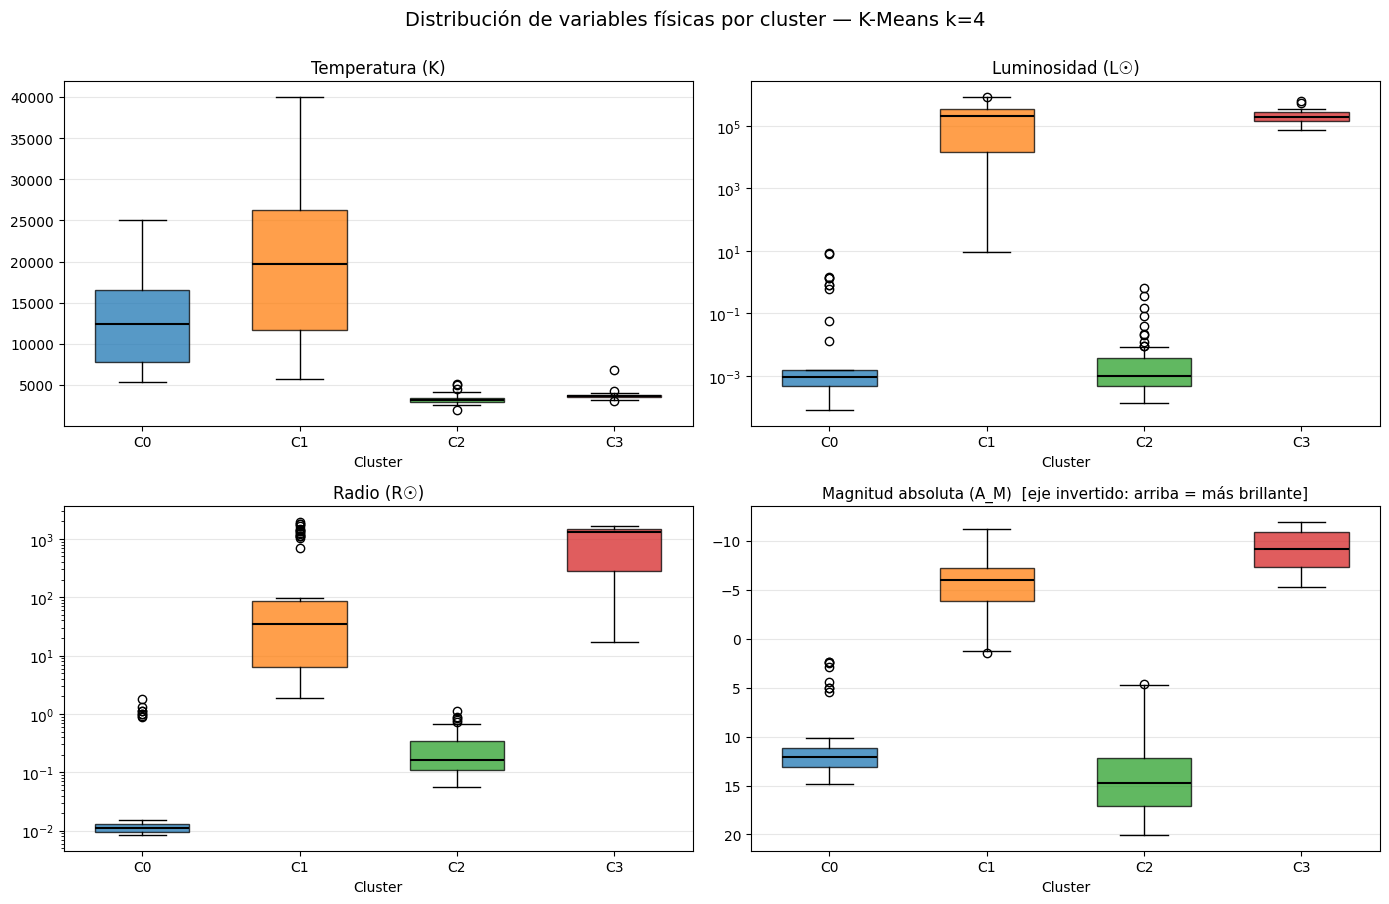

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

variables = [
    ("Temperature", "Temperatura (K)",         "linear"),
    ("L",           "Luminosidad (L☉)",         "log"),
    ("R",           "Radio (R☉)",               "log"),
    ("A_M",         "Magnitud absoluta (A_M)",  "linear"),
]

for ax, (var, label, scale) in zip(axes.flat, variables):
    data_per_cluster = [
        df_master.loc[df_master["cluster_kmeans"] == c, var].values
        for c in range(K_FINAL)
    ]
    bp = ax.boxplot(
        data_per_cluster,
        patch_artist=True,
        labels=[f"C{i}" for i in range(K_FINAL)],
        widths=0.6,
        medianprops=dict(color="black", linewidth=1.5),
    )
    for patch, i in zip(bp["boxes"], range(K_FINAL)):
        patch.set_facecolor(plt.cm.tab10(i / 10))
        patch.set_alpha(0.75)

    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Cluster")
    ax.set_yscale(scale)
    ax.grid(alpha=0.3, axis="y")

    if var == "A_M":
        ax.invert_yaxis()
        ax.set_title(label + "  [eje invertido: arriba = más brillante]", fontsize=11)

plt.suptitle("Distribución de variables físicas por cluster — K-Means k=4",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Las medias y modas de las variables originales muestran que cada cluster corresponde a una población estelar reconocible. Cruzando los perfiles obtenidos con la tabla astronómica del enunciado:

- **Cluster 0 (n=48):** temperatura intermedia-alta (~12.700 K), pero con luminosidad y radio muy bajos (L≈0.48 L☉, R≈0.20 R☉) y magnitud absoluta extremadamente alta (A_M≈+11.1). Color modal *blue-white* y clase espectral B. La combinación "caliente pero pequeña y débil" es el perfil de las **enanas blancas**: estrellas en fase final con masa concentrada en un volumen muy pequeño. Los outliers visibles en los boxplots de L y R sugieren cierta heterogeneidad interna, posiblemente con contaminación de subenanas o objetos pre-secuencia principal de baja masa.

- **Cluster 1 (n=74):** temperatura muy alta (~20.500 K), luminosidad y radio enormes (L≈240.000 L☉, R≈300 R☉), A_M muy brillante (-5.43). Color modal *blue* y clase espectral O. Estos parámetros corresponden a **supergigantes**, con un sesgo hacia tipos O-B (las más calientes de la familia). Las medias coinciden razonablemente con la fila "Super gigante" del enunciado en orden de magnitud, aunque con un perfil térmico más extremo.

- **Cluster 2 (n=84):** temperatura muy baja (~3.200 K), luminosidad y radio mínimos (L≈0.02 L☉, R≈0.26 R☉), A_M muy alta (+14.6). Color modal *red* y clase espectral M. Este perfil agrupa **enanas rojas y enanas marrones** simultáneamente. Las dos primeras filas de la tabla del enunciado ("Enana roja" y "Enana marrón") tienen parámetros muy similares (mismo color, misma clase espectral, temperaturas y radios cercanos), por lo que su fusión en un único cluster es esperable: la frontera entre ambos tipos no se manifiesta con suficiente claridad en el espacio PCA con k=4.

- **Cluster 3 (n=34):** temperatura baja (~3.700 K) pero combinada con luminosidad gigantesca (L≈234.000 L☉) y radio descomunal (R≈1.020 R☉), con A_M=-9.0. Color modal *red* y clase espectral M. La combinación "fría + luminosa + enorme" es la firma de las **hipergigantes rojas**. Los valores coinciden estrechamente con la fila "Hiper gigante" del enunciado salvo por el color (la tabla cita "amarilla" como color modal de hipergigante; este cluster captura específicamente la subclase roja).

**Síntesis y limitaciones del clustering con k=4.**

K-Means con k=4 identifica **cuatro de las seis clases del enunciado**: enanas blancas, supergigantes, "enanas frías" (fusión de enanas rojas y marrones) e hipergigantes rojas. La pérdida de granularidad respecto a las seis clases astronómicas tiene dos causas:

1. **Fusión de tipos adyacentes:** enanas rojas y enanas marrones comparten color, clase espectral y rango térmico, por lo que K-Means las agrupa en el Cluster 2.
2. **Ausencia de cluster específico para secuencia principal:** la tabla del enunciado describe estrellas en secuencia principal con parámetros intermedios (T=16.000, L=32.000, R=4.4, A_M=-0.4) que no coinciden con ningún centroide de los cuatro clusters. Probablemente estas estrellas se han distribuido entre los Clusters 0 y 1 según su masa y temperatura, sin formar un grupo propio.

Esta correspondencia 4:6 es metodológicamente coherente con la elección de k. Las cuatro métricas del 2.2 votaron por k=4 sobre k=5 o k=6, indicando que la estructura geométrica del dataset prefiere cuatro grupos sobre la clasificación humana de seis. Esta tensión entre estructura geométrica y clasificación astronómica es información valiosa para la discusión final del Bloque 5 y especialmente del Bloque 6.

## 3. Clustering Jerárquico

Aplicamos el segundo algoritmo exigido por el enunciado: clustering jerárquico aglomerativo. A diferencia de K-Means, este enfoque no requiere fijar `k` a priori: construye una jerarquía completa de fusiones y permite "cortar" el dendrograma a la altura deseada.

A diferencia del Bloque 2, aquí el espacio de búsqueda es **bidimensional**: hay que elegir simultáneamente la función de **linkage** (que define cómo se mide la distancia entre clusters) y el número de cortes `k`. Por tanto, en lugar de un barrido unidimensional, planteamos una **rejilla 2D linkage × k** y seleccionamos la mejor combinación mediante un ranking medio sobre tres métricas. Estructuramos el bloque en cuatro pasos: rejilla 2D y ranking, dendrograma del ganador, modelo final con visualización en PCA, y comparación directa con K-Means.

### 3.1 Rejilla 2D: linkage × k

Probamos los cuatro linkages estándar con valores de `k` entre 2 y 8, evaluando cada combinación con las mismas tres métricas usadas en el Bloque 2 (silhouette, Davies-Bouldin, Calinski-Harabasz).

**Linkages probados.** Cada función mide la distancia entre clusters de forma distinta: `ward` minimiza la varianza intra-cluster (tiende a producir grupos compactos y de tamaño similar), `complete` usa la distancia máxima entre puntos (sensible a outliers), `average` usa la distancia media (compromiso intermedio), `single` usa la distancia mínima (puede producir efecto de cadena en clusters alargados).

**Selección por ranking medio (pesos iguales 1/3 cada métrica).** Cada una de las 28 combinaciones (4 linkages × 7 valores de k) se rankea contra las otras 27 según cada métrica por separado. La combinación con menor posición media gana. Pesos iguales evita introducir sesgos a priori; el sesgo conocido de CH a k altos se compensa naturalmente cuando hay consenso entre las otras dos métricas.

In [29]:
from scipy.cluster.hierarchy import linkage, fcluster

LINKAGES = ["ward", "complete", "average", "single"]
K_RANGE_HIER = range(2, 9)

# Calculamos la matriz de linkage una sola vez por método para no repetir trabajo
linkage_matrices = {m: linkage(X_clust, method=m) for m in LINKAGES}

# Evaluamos cada combinación (linkage, k) con las tres métricas
filas = []
for method in LINKAGES:
    Z = linkage_matrices[method]
    for k in K_RANGE_HIER:
        labels_h = fcluster(Z, t=k, criterion="maxclust")

        # Si fcluster produce menos clusters de los pedidos las métricas fallan,
        # dejamos NaN para que no contaminen el ranking
        if len(np.unique(labels_h)) < 2:
            sil = db = ch = np.nan
        else:
            sil = silhouette_score(X_clust, labels_h)
            db  = davies_bouldin_score(X_clust, labels_h)
            ch  = calinski_harabasz_score(X_clust, labels_h)

        filas.append({
            "linkage": method, "k": k,
            "silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch,
        })

df_grid = pd.DataFrame(filas)

# Calculamos el ranking medio para cada combinación:
# silhouette y CH se maximizan, DBI se minimiza
df_grid["rank_silhouette"] = df_grid["silhouette"].rank(ascending=False, method="min")
df_grid["rank_db"]         = df_grid["davies_bouldin"].rank(ascending=True,  method="min")
df_grid["rank_ch"]         = df_grid["calinski_harabasz"].rank(ascending=False, method="min")
df_grid["rank_medio"]      = (df_grid["rank_silhouette"] + df_grid["rank_db"] + df_grid["rank_ch"]) / 3

# Combinación ganadora
ganador      = df_grid.loc[df_grid["rank_medio"].idxmin()]
best_linkage = ganador["linkage"]
best_k_hier  = int(ganador["k"])

print(f"Combinación ganadora:")
print(f"  Linkage:            '{best_linkage}'")
print(f"  k:                  {best_k_hier}")
print(f"  Rank medio:         {ganador['rank_medio']:.2f}")
print(f"  Silhouette:         {ganador['silhouette']:.4f}")
print(f"  Davies-Bouldin:     {ganador['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz:  {ganador['calinski_harabasz']:.2f}")

Combinación ganadora:
  Linkage:            'average'
  k:                  5
  Rank medio:         5.33
  Silhouette:         0.7278
  Davies-Bouldin:     0.4464
  Calinski-Harabasz:  1218.36


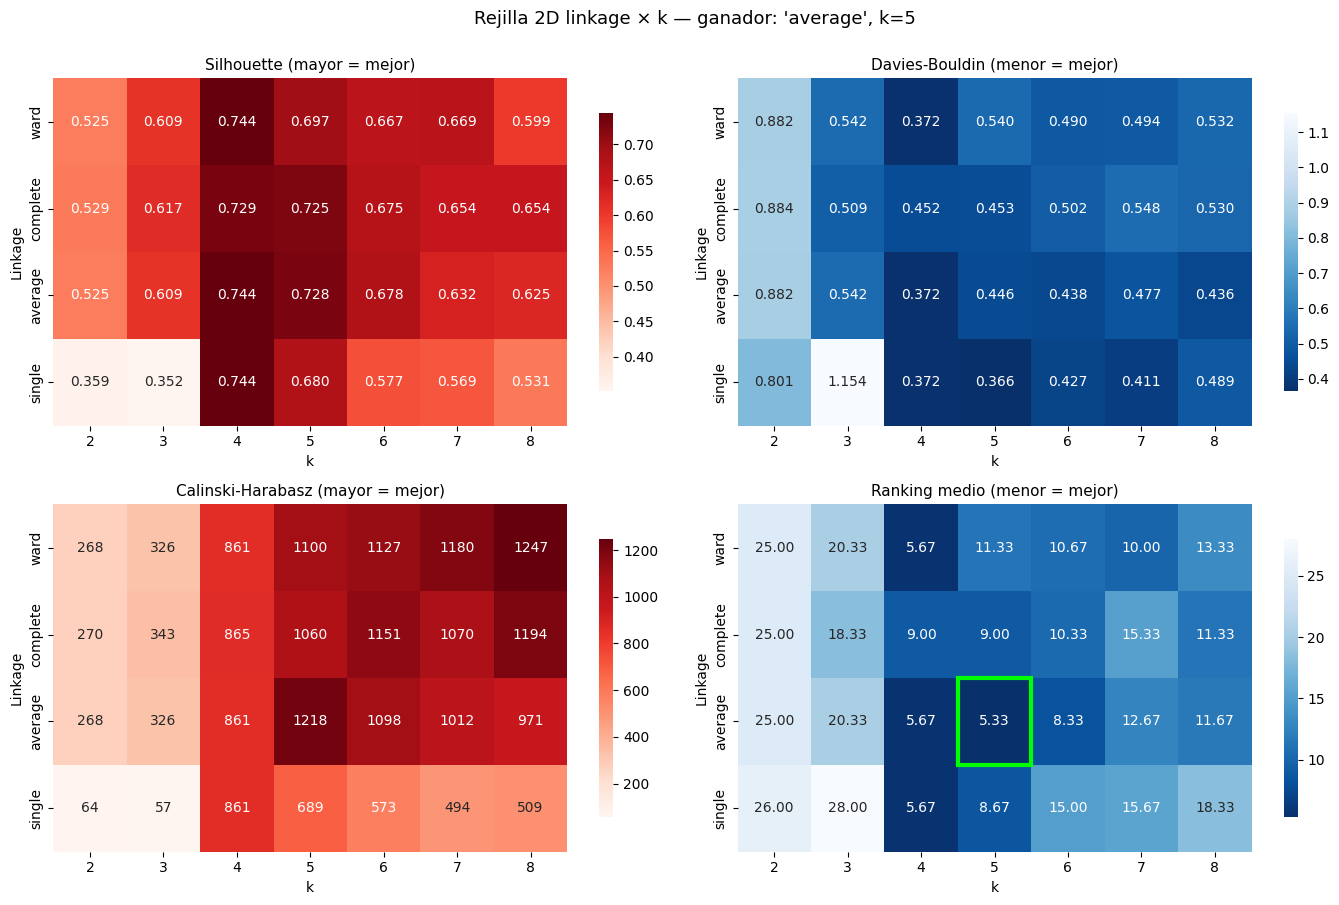

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

heatmap_specs = [
    ("silhouette",        "Silhouette (mayor = mejor)",      "Reds",    False),
    ("davies_bouldin",    "Davies-Bouldin (menor = mejor)",  "Blues_r", False),
    ("calinski_harabasz", "Calinski-Harabasz (mayor = mejor)", "Reds",  False),
    ("rank_medio",        "Ranking medio (menor = mejor)",   "Blues_r", True),
]

for ax, (col, title, cmap, is_rank) in zip(axes.flat, heatmap_specs):
    pivot = df_grid.pivot(index="linkage", columns="k", values=col).reindex(LINKAGES)
    fmt = ".2f" if is_rank else (".3f" if col != "calinski_harabasz" else ".0f")
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("k")
    ax.set_ylabel("Linkage")

# Marcamos la celda ganadora con un borde verde en el heatmap del ranking
ax_rank = axes[1, 1]
i_row = LINKAGES.index(best_linkage)
j_col = list(K_RANGE_HIER).index(best_k_hier)
ax_rank.add_patch(plt.Rectangle((j_col, i_row), 1, 1, fill=False,
                                edgecolor="lime", linewidth=3))

plt.suptitle(f"Rejilla 2D linkage × k — ganador: '{best_linkage}', k={best_k_hier}",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

### 3.2 Dendrograma del linkage ganador

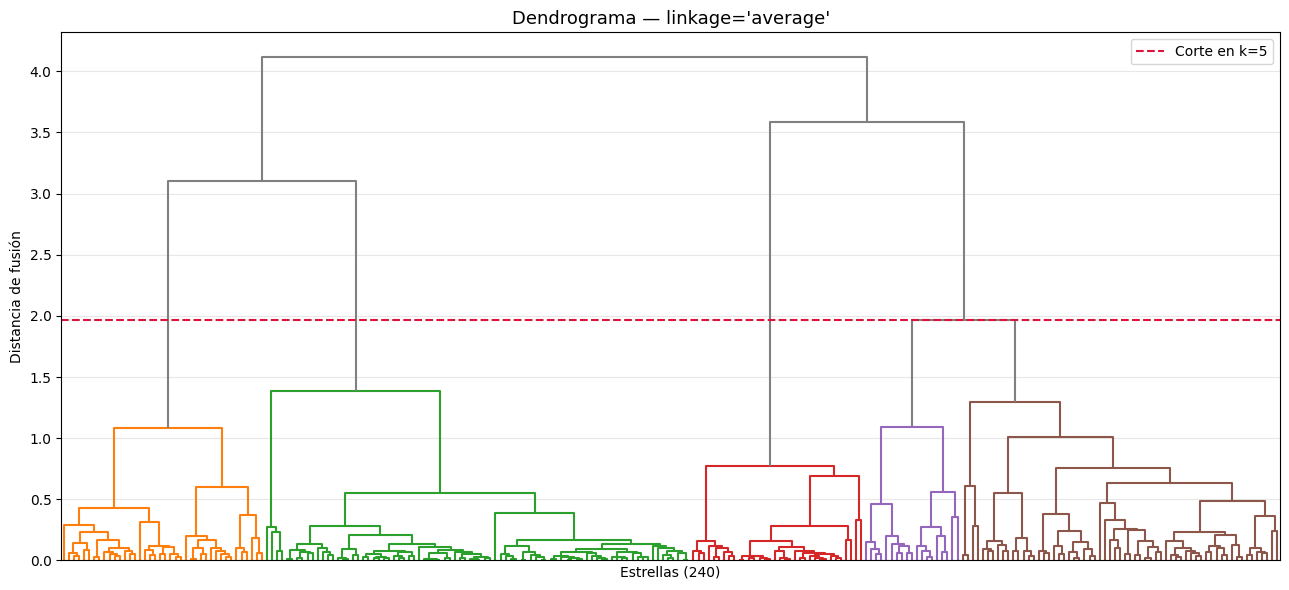

In [31]:
from scipy.cluster.hierarchy import dendrogram

Z_best = linkage_matrices[best_linkage]

# Altura a la que cortar el árbol para obtener exactamente best_k_hier clusters
cut_height = Z_best[-(best_k_hier - 1), 2]

fig, ax = plt.subplots(figsize=(13, 6))
dendrogram(
    Z_best,
    color_threshold=cut_height,
    above_threshold_color="gray",
    no_labels=True,
    ax=ax,
)
ax.axhline(cut_height, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Corte en k={best_k_hier}")
ax.set_title(f"Dendrograma — linkage='{best_linkage}'", fontsize=13)
ax.set_xlabel("Estrellas (240)")
ax.set_ylabel("Distancia de fusión")
ax.legend(loc="upper right")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

El árbol revela la estructura jerárquica completa de los datos, información que se pierde al elegir un único valor de `k`. Tres observaciones relevantes:

- **Dos macro-grupos en la raíz.** La fusión final del árbol ocurre a una altura considerable (≈4.1), uniendo dos grandes ramas que en el corte k=5 corresponden, aproximadamente, a estrellas frías-pequeñas (rama derecha) y estrellas calientes-luminosas (rama izquierda). Esta bifurcación inicial coincide con la separación más fundamental del diagrama HR.
- **Subestructura asimétrica.** La rama izquierda se subdivide pronto en tres subgrupos a alturas similares (≈3.1, ≈1.4, ≈1.1), mientras que la rama derecha mantiene mayor cohesión hasta alturas más bajas. Esta asimetría refleja que las poblaciones estelares calientes son más heterogéneas que las frías en el espacio PCA.
- **Robustez del corte k=5.** La línea de corte (≈1.97) intersecta el árbol en una zona donde las distancias verticales entre fusiones son notables, indicando que k=5 corresponde a un nivel de granularidad estructuralmente coherente. Cortar a k=4 (altura ≈3.1) o k=6 (altura ≈1.4) también daría particiones razonables, pero k=5 ocupa una "meseta" de estabilidad jerárquica.

### 3.3 Modelo final y comparación con K-Means

Con el linkage y `k` ya seleccionados, materializamos el modelo final: persistimos las etiquetas en `df_master["cluster_hier"]`, calculamos las métricas definitivas y visualizamos la partición en el plano PCA. Adicionalmente, calculamos el **Adjusted Rand Index (ARI)** entre esta partición y la de K-Means del Bloque 2: una métrica que cuantifica cuán similares son dos particiones independientemente del nombre de las etiquetas, permitiendo comparar honestamente algoritmos con `k` distinto.

Métricas del modelo jerárquico final:
  Linkage:            'average', k=5
  Silhouette:         0.7278
  Davies-Bouldin:     0.4464
  Calinski-Harabasz:  1218.36

ARI vs K-Means: 0.9000  (1.0 = particiones idénticas)


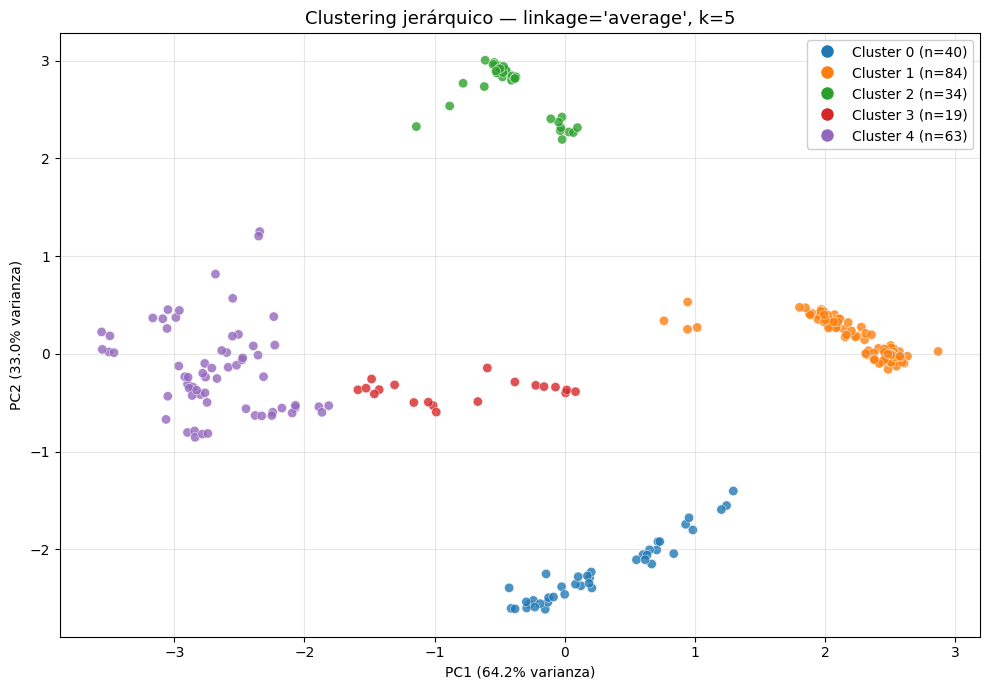


Tamaños finales por cluster:
cluster_hier
0    40
1    84
2    34
3    19
4    63


In [32]:
from sklearn.metrics import adjusted_rand_score

# Convertimos a índice 0-based para que sea consistente con K-Means
labels_hier = fcluster(Z_best, t=best_k_hier, criterion="maxclust") - 1
df_master["cluster_hier"] = labels_hier

sil_h = silhouette_score(X_clust, labels_hier)
db_h  = davies_bouldin_score(X_clust, labels_hier)
ch_h  = calinski_harabasz_score(X_clust, labels_hier)

# El ARI mide cuánto se parecen dos particiones independientemente
# del nombre de las etiquetas (1.0 = idénticas, 0.0 = aleatorias)
ari_kmeans_hier = adjusted_rand_score(df_master["cluster_kmeans"], df_master["cluster_hier"])

print(f"Métricas del modelo jerárquico final:")
print(f"  Linkage:            '{best_linkage}', k={best_k_hier}")
print(f"  Silhouette:         {sil_h:.4f}")
print(f"  Davies-Bouldin:     {db_h:.4f}")
print(f"  Calinski-Harabasz:  {ch_h:.2f}")
print(f"\nARI vs K-Means: {ari_kmeans_hier:.4f}  (1.0 = particiones idénticas)")

# Visualización en el plano PCA
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df_pca["PC1"], df_pca["PC2"],
    c=labels_hier, cmap="tab10",
    s=45, alpha=0.8, edgecolors="white", linewidths=0.4,
    vmin=0, vmax=9,
)

handles = [
    plt.Line2D([], [], marker="o", linestyle="",
               color=plt.cm.tab10(i / 10), markersize=10,
               markeredgecolor="white",
               label=f"Cluster {i} (n={(labels_hier == i).sum()})")
    for i in range(best_k_hier)
]
ax.legend(handles=handles, loc="best", framealpha=0.95)
ax.set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
ax.set_title(f"Clustering jerárquico — linkage='{best_linkage}', k={best_k_hier}", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTamaños finales por cluster:")
print(df_master["cluster_hier"].value_counts().sort_index().to_string())

### 3.4 Discusión

**Resultado del procedimiento.** El ranking medio sobre las 28 combinaciones (4 linkages × 7 valores de k) selecciona **linkage='average' con k=5** como ganador, con métricas finales: silhouette = 0.7278, Davies-Bouldin = 0.4464 y Calinski-Harabasz = 1218.36.

**Lectura honesta del resultado.** Examinando el heatmap del ranking medio se observa que k=4 con el mismo linkage `average` queda muy cerca del ganador (rank medio 5.67 vs 5.33). Inspeccionando las métricas individuales, el desempate revela un patrón conocido:

- **Silhouette:** mejor en k=4 (0.744 vs 0.728).
- **Davies-Bouldin:** mejor en k=4 (0.372 vs 0.446).
- **Calinski-Harabasz:** mejor en k=5 (1218 vs 861).

Es decir, **dos de las tres métricas favorecen k=4**, y k=5 gana únicamente porque CH dispara en ese punto. Esta situación es coherente con el sesgo de CH discutido en el subapartado 2.3 (el factor `(n-k)/(k-1)` penaliza poco k altos en datasets pequeños).

**Por qué mantenemos k=5 a pesar de esta tensión.** A pesar del sesgo de CH, la inspección visual del scatter en PC1-PC2 muestra que la subdivisión adicional que produce k=5 sobre k=4 es **geométricamente y físicamente válida**. El cluster que K-Means etiquetaba como "estrellas calientes y luminosas" (n=74) se desdobla aquí en dos subgrupos visualmente diferenciados: una zona izquierda amplia (Cluster 4, n=63) y una franja central más compacta (Cluster 3, n=19). Esta separación recupera precisamente la granularidad que en el subapartado 2.7 identificamos como ausente en K-Means: la distinción entre **estrellas en secuencia principal masiva** (la franja central) y **supergigantes** (la zona izquierda extendida), dos poblaciones que K-Means fusionaba.

**Comparación con K-Means: ARI = 0.90.** Un valor tan alto entre particiones con k distinto (4 vs 5) confirma que jerárquico no descubre una estructura radicalmente distinta, sino que **preserva tres clusters de K-Means casi idénticos** (Cluster 1 jerárquico ≈ Cluster 2 K-Means con n=84; Cluster 2 jerárquico ≈ Cluster 3 K-Means con n=34; Cluster 0 jerárquico ≈ Cluster 0 K-Means con n=48 vs 40, mínima reasignación) y aporta valor en la subdivisión del cluster restante.

**Síntesis del bloque.** El clustering jerárquico con linkage `average` y k=5 no contradice a K-Means: lo refina. Identifica una estructura compatible con cinco poblaciones estelares en lugar de cuatro, recuperando una distinción astronómicamente relevante (secuencia principal vs supergigantes) que K-Means no podía capturar por su asunción de clusters esféricos. Esta es exactamente la situación esperable cuando un algoritmo no-paramétrico tiene más flexibilidad geométrica que uno paramétrico. La comparación final con DBSCAN en el Bloque 5 permitirá decidir cuál de los tres algoritmos ofrece el mejor compromiso entre rigor estadístico e interpretabilidad astronómica.

## 4. Clustering con DBSCAN

Aplicamos el tercer y último algoritmo exigido por el enunciado: DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*). A diferencia de K-Means y jerárquico, DBSCAN no requiere fijar el número de clusters: los descubre automáticamente a partir de criterios de densidad. Además, identifica explícitamente puntos de **ruido** (outliers no asignables a ningún cluster), lo cual es valioso astronómicamente: estrellas atípicas o transiciones entre poblaciones pueden no encajar en ninguna categoría estándar.

DBSCAN tiene dos hiperparámetros: **`eps`** (radio de vecindad) y **`min_samples`** (densidad mínima para formar un núcleo). El enunciado pide usar la métrica **DBCV** (Density-Based Clustering Validation, Moulavi et al. 2014) para evaluar las configuraciones, métrica que no está en scikit-learn y obtenemos de la librería `hdbscan`.

Estructuramos el bloque en cinco pasos: heurística k-distance plot para acotar `eps`, grid search 2D con DBCV, análisis de estabilidad de la región ganadora, modelo final con visualización en PCA, y comparación con los algoritmos previos.

### 4.1 Heurística k-distance plot

La heurística estándar de DBSCAN (Ester et al. 1996) sugiere fijar `eps` como el "codo" de la gráfica de distancias al k-ésimo vecino más cercano de cada punto, ordenadas ascendentemente. La intuición: la mayoría de los puntos tienen vecinos cercanos (distancias bajas), pero los puntos en la frontera o en regiones poco densas tienen distancias mayores. El codo separa ambas regiones.

Usamos esta heurística para **identificar el rango natural de `eps`** que luego exploraremos con el grid search. No la utilizamos como criterio único de selección porque la elección heurística suele ser conservadora; el grid + DBCV puede encontrar configuraciones mejores que la heurística pierde.

**Convención:** `k = min_samples`. Probamos varios valores de `k` para ver cómo varía el codo.

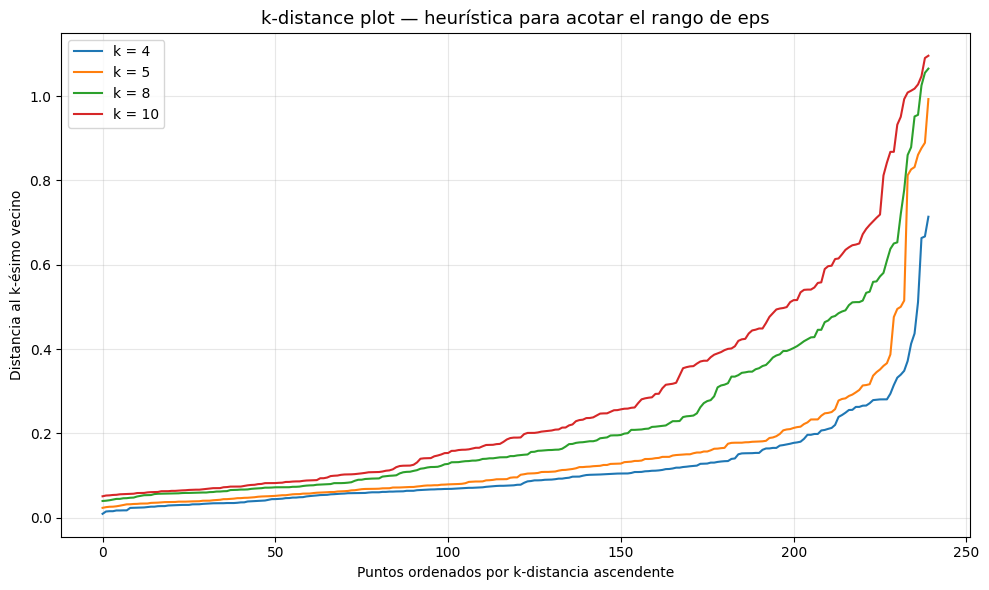

El codo de cada curva indica un valor razonable de eps para ese k.
El grid search explorará un rango amplio alrededor de esos valores.


In [33]:
from sklearn.neighbors import NearestNeighbors

# Probamos varios valores de k para ver cómo varía el codo
# y así identificar el rango natural de eps antes del grid search
K_VALUES_HEURISTIC = [4, 5, 8, 10]

fig, ax = plt.subplots(figsize=(10, 6))

for k in K_VALUES_HEURISTIC:
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_clust)
    distances, _ = nbrs.kneighbors(X_clust)
    # Tomamos la distancia al k-ésimo vecino de cada punto y las ordenamos
    k_distances = np.sort(distances[:, k - 1])
    ax.plot(k_distances, label=f"k = {k}")

ax.set_xlabel("Puntos ordenados por k-distancia ascendente")
ax.set_ylabel("Distancia al k-ésimo vecino")
ax.set_title("k-distance plot — heurística para acotar el rango de eps", fontsize=13)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("El codo de cada curva indica un valor razonable de eps para ese k.")
print("El grid search explorará un rango amplio alrededor de esos valores.")

Las cuatro curvas presentan el comportamiento característico esperado: crecimiento muy suave hasta el punto ~200 (la mayoría de los puntos tienen vecinos cercanos) y un **codo pronunciado en el extremo derecho** que separa la masa de puntos densos de los aislados. La altura del codo varía con `k`: para `k=4` el codo aparece en torno a eps≈0.3-0.4, mientras que para `k=10` se desplaza a eps≈0.5-0.7. Esto es metodológicamente útil: confirma que el rango natural de `eps` se sitúa aproximadamente entre 0.3 y 0.7, dentro del cual el grid search posterior (que cubre 0.05-1.5) tiene resolución suficiente. Las regiones extremas del grid (eps<0.1 o eps>1.0) explorarán configuraciones degeneradas, pero la zona central del grid coincide con la sugerencia heurística.

### 4.2 Grid search 2D con DBCV

Exploramos sistemáticamente el espacio bidimensional `(eps, min_samples)`:

- **`eps`:** 25 valores en escala logarítmica entre 0.05 y 1.5. Escala logarítmica porque el efecto de `eps` no es lineal: dobles `eps` no producen dobles clusters.
- **`min_samples`:** 8 valores `{2, 3, 4, 5, 6, 8, 10, 15}`, cubriendo desde configuraciones permisivas hasta exigentes.

Total: 200 combinaciones. Para cada una entrenamos DBSCAN y calculamos DBCV, número de clusters y porcentaje de outliers. **Filtro suave:** las configuraciones que producen menos de 2 clusters dan DBCV indefinido (NaN); las dejamos visibles en el heatmap como zona vacía.

**Sobre por qué no usamos búsqueda bayesiana en DBSCAN.** A pesar de tener un espacio bidimensional, DBCV es ruidoso y discontinuo: pequeñas variaciones de `eps` pueden producir cambios bruscos en el clustering. Las funciones de adquisición bayesianas asumen suavidad y trabajan mal con paisajes así. El estándar profesional en DBSCAN es grid amplio + análisis de estabilidad post-hoc, que es lo que aplicamos.

In [34]:
from sklearn.cluster import DBSCAN
from hdbscan.validity import validity_index

# 25 valores de eps en escala logarítmica porque su efecto no es lineal
EPS_VALUES = np.logspace(np.log10(0.05), np.log10(1.5), 25)
MS_VALUES  = [2, 3, 4, 5, 6, 8, 10, 15]

X_dbcv = X_clust.astype(np.float64)

filas = []

for ms in MS_VALUES:
    for eps in EPS_VALUES:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_db = db.fit_predict(X_dbcv)

        n_clusters  = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_outliers  = (labels_db == -1).sum()
        pct_outliers = n_outliers / len(labels_db) * 100

        # DBCV necesita al menos 2 clusters para tener sentido
        if n_clusters < 2:
            dbcv = np.nan
        else:
            try:
                dbcv = validity_index(X_dbcv, labels_db)
            except Exception:
                dbcv = np.nan

        filas.append({
            "eps": eps, "min_samples": ms,
            "n_clusters": n_clusters,
            "pct_outliers": pct_outliers,
            "dbcv": dbcv,
        })

df_dbscan = pd.DataFrame(filas)

n_validas = df_dbscan["dbcv"].notna().sum()
print(f"Grid completado: {len(df_dbscan)} combinaciones evaluadas, {n_validas} con DBCV definido.\n")

print("Top 10 configuraciones por DBCV:")
print(df_dbscan.dropna().nlargest(10, "dbcv").to_string(index=False))

Grid completado: 200 combinaciones evaluadas, 196 con DBCV definido.

Top 10 configuraciones por DBCV:
     eps  min_samples  n_clusters  pct_outliers     dbcv
0.556243           15           4      7.916667 0.770043
0.556243           10           4      5.833333 0.764865
0.640931           15           4      6.250000 0.761742
0.738512           15           4      4.583333 0.734458
0.482745           10           4     12.083333 0.730030
0.640931           10           4      3.750000 0.725693
0.850951            6           4      1.250000 0.718591
0.850951            8           4      1.250000 0.718591
0.850951           10           4      1.250000 0.718591
0.850951           15           4      1.250000 0.718591


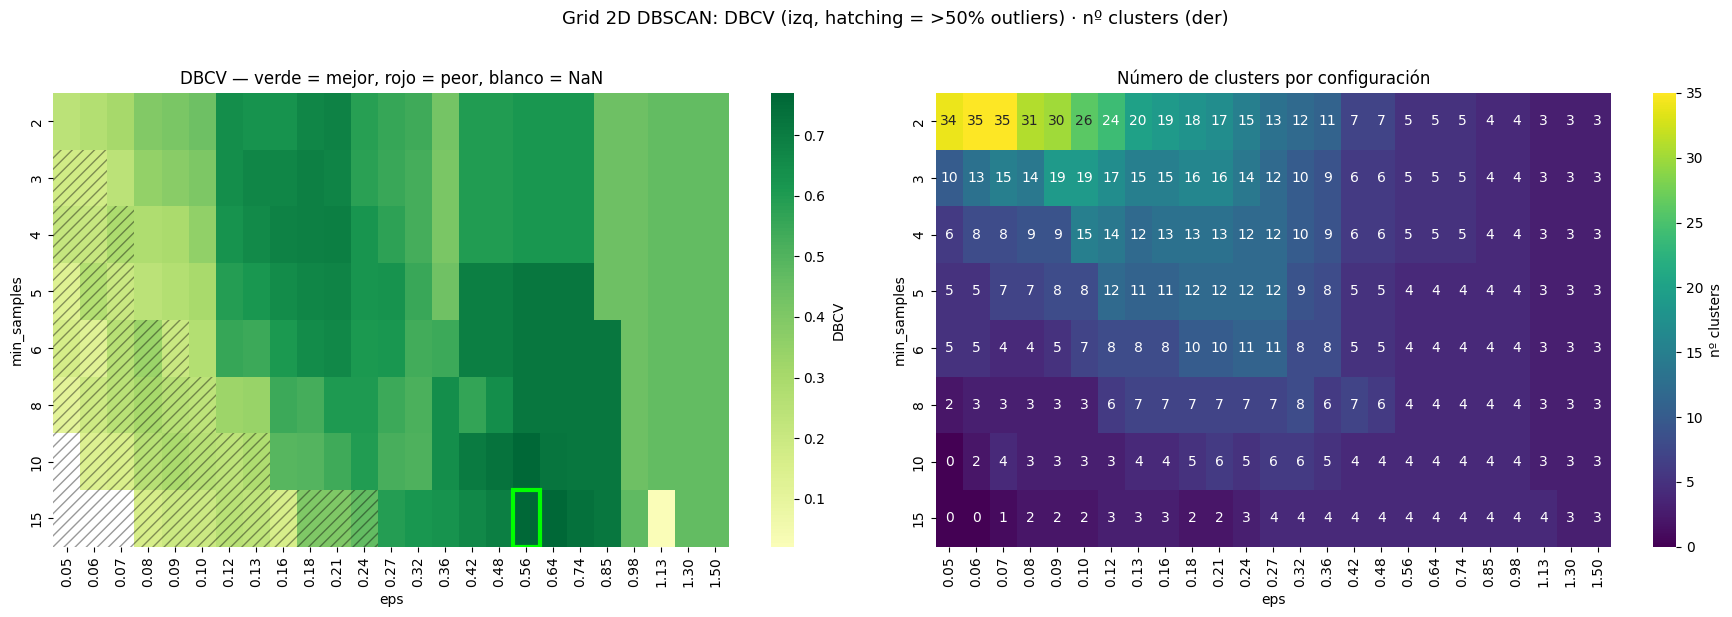

Configuración ganadora:
  eps:          0.5562
  min_samples:  15
  DBCV:         0.7700
  nº clusters:  4
  % outliers:   7.9%


In [35]:
pivot_dbcv     = df_dbscan.pivot(index="min_samples", columns="eps", values="dbcv")
pivot_nclust   = df_dbscan.pivot(index="min_samples", columns="eps", values="n_clusters")
pivot_outliers = df_dbscan.pivot(index="min_samples", columns="eps", values="pct_outliers")

eps_labels = [f"{e:.2f}" for e in EPS_VALUES]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap principal: DBCV
sns.heatmap(pivot_dbcv, ax=axes[0], cmap="RdYlGn", center=0,
            xticklabels=eps_labels, yticklabels=MS_VALUES,
            cbar_kws={"label": "DBCV"}, annot=False)
axes[0].set_title("DBCV — verde = mejor, rojo = peor, blanco = NaN", fontsize=12)
axes[0].set_xlabel("eps")
axes[0].set_ylabel("min_samples")

# Marcamos con hatching las celdas con más del 50% de outliers
for i, ms in enumerate(MS_VALUES):
    for j, eps in enumerate(EPS_VALUES):
        pct = pivot_outliers.loc[ms, EPS_VALUES[j]]
        if pct > 50:
            axes[0].add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                            hatch="///", edgecolor="black",
                                            linewidth=0, alpha=0.4))

# Marcamos la combinación ganadora con un borde verde
ganadora_idx = df_dbscan["dbcv"].idxmax()
ganadora     = df_dbscan.loc[ganadora_idx]
i_win = MS_VALUES.index(int(ganadora["min_samples"]))
j_win = list(EPS_VALUES).index(ganadora["eps"])
axes[0].add_patch(plt.Rectangle((j_win, i_win), 1, 1, fill=False,
                                edgecolor="lime", linewidth=3))

# Heatmap auxiliar: número de clusters
sns.heatmap(pivot_nclust, ax=axes[1], cmap="viridis",
            xticklabels=eps_labels, yticklabels=MS_VALUES,
            cbar_kws={"label": "nº clusters"}, annot=True, fmt=".0f")
axes[1].set_title("Número de clusters por configuración", fontsize=12)
axes[1].set_xlabel("eps")
axes[1].set_ylabel("min_samples")

plt.suptitle("Grid 2D DBSCAN: DBCV (izq, hatching = >50% outliers) · nº clusters (der)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Configuración ganadora:")
print(f"  eps:          {ganadora['eps']:.4f}")
print(f"  min_samples:  {int(ganadora['min_samples'])}")
print(f"  DBCV:         {ganadora['dbcv']:.4f}")
print(f"  nº clusters:  {int(ganadora['n_clusters'])}")
print(f"  % outliers:   {ganadora['pct_outliers']:.1f}%")

### 4.3 Análisis de estabilidad de la región ganadora

Antes de aceptar la configuración con DBCV máximo, verificamos que **no es un pico aislado** producto de ruido en la métrica. La idea: si la combinación ganadora está rodeada en el grid de configuraciones también con DBCV alto, es una zona robusta. Si es un pico solitario, podría ser azar.

Calculamos el DBCV medio en la **vecindad 3×3** del ganador (la celda ganadora más sus 8 vecinas en el grid). Si el promedio de la vecindad sigue siendo alto, la zona es estable.

In [36]:
# Comprobamos que la celda ganadora no sea un pico aislado
# calculando el DBCV medio en su vecindad 3x3
i_win = MS_VALUES.index(int(ganadora["min_samples"]))
j_win = list(EPS_VALUES).index(ganadora["eps"])

i_lo, i_hi = max(0, i_win - 1), min(len(MS_VALUES), i_win + 2)
j_lo, j_hi = max(0, j_win - 1), min(len(EPS_VALUES), j_win + 2)

vecindad_dbcv   = pivot_dbcv.iloc[i_lo:i_hi, j_lo:j_hi].values
vecindad_validas = vecindad_dbcv[~np.isnan(vecindad_dbcv)]

dbcv_ganador          = ganadora["dbcv"]
dbcv_vecindad_media   = vecindad_validas.mean() if len(vecindad_validas) > 0 else np.nan
dbcv_vecindad_min     = vecindad_validas.min()  if len(vecindad_validas) > 0 else np.nan
ratio = dbcv_vecindad_media / dbcv_ganador if dbcv_ganador > 0 else np.nan

print(f"Análisis de estabilidad de la región ganadora:")
print(f"  DBCV en la celda ganadora:       {dbcv_ganador:.4f}")
print(f"  DBCV medio en vecindad 3x3:      {dbcv_vecindad_media:.4f}")
print(f"  DBCV mínimo en vecindad 3x3:     {dbcv_vecindad_min:.4f}")
print(f"  Ratio media vecindad / ganador:  {ratio:.3f}")
print(f"  Celdas válidas en la vecindad:   {len(vecindad_validas)} de {vecindad_dbcv.size}")

if ratio > 0.85:
    veredicto = "Región estable: el ganador está en una meseta de alto DBCV."
elif ratio > 0.65:
    veredicto = "Región aceptable: DBCV alto en la vecindad pero con cierta variabilidad."
else:
    veredicto = "Pico aislado: el ganador podría no ser representativo, conviene revisar."
print(f"\n  {veredicto}")

Análisis de estabilidad de la región ganadora:
  DBCV en la celda ganadora:       0.7700
  DBCV medio en vecindad 3x3:      0.7413
  DBCV mínimo en vecindad 3x3:     0.6956
  Ratio media vecindad / ganador:  0.963
  Celdas válidas en la vecindad:   6 de 6

  Región estable: el ganador está en una meseta de alto DBCV.


### 4.4 Modelo final y comparación con K-Means y Jerárquico

Métricas del modelo DBSCAN final:
  eps:                           0.5562
  min_samples:                   15
  Nº clusters:                   4
  Outliers:                      19 puntos (7.9%)
  DBCV:                          0.7700
  Silhouette (sin ruido):        0.8189
  Davies-Bouldin (sin ruido):    0.2829
  Calinski-Harabasz (sin ruido): 1751.72

ARI vs K-Means:    0.8884
ARI vs Jerárquico: 0.9074


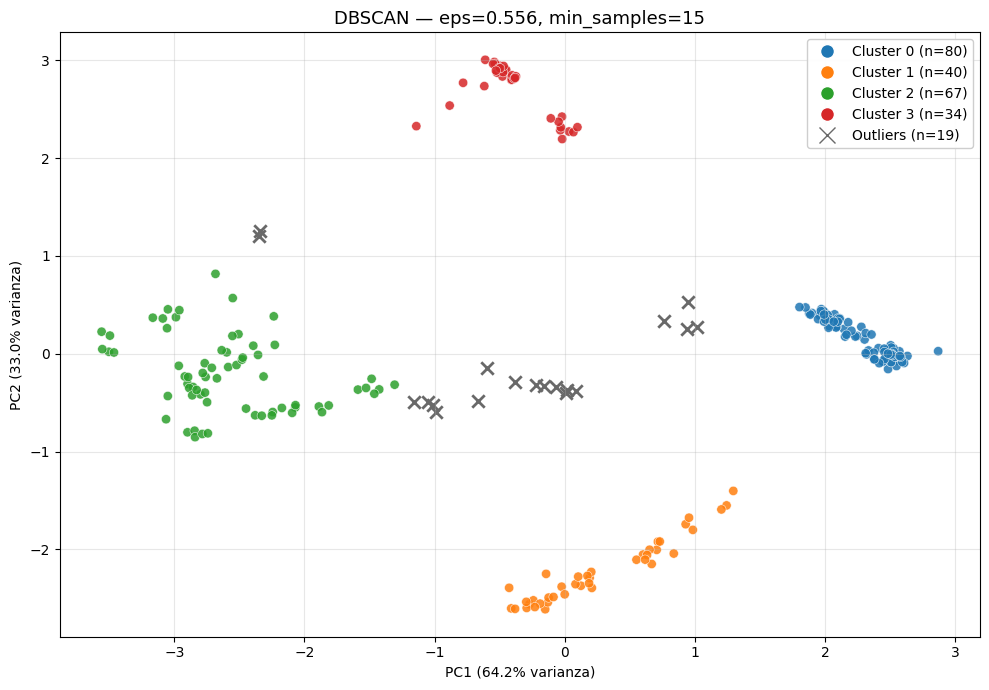

In [37]:
# Entrenamos el modelo definitivo con la configuración ganadora del grid
db_final = DBSCAN(
    eps=ganadora["eps"],
    min_samples=int(ganadora["min_samples"]),
)
labels_dbscan = db_final.fit_predict(X_dbcv)
df_master["cluster_dbscan"] = labels_dbscan

# Las métricas clásicas se calculan excluyendo el ruido (-1),
# ya que están diseñadas para puntos asignados a clusters
mask_no_ruido = labels_dbscan != -1
if mask_no_ruido.sum() > 0 and len(set(labels_dbscan[mask_no_ruido])) > 1:
    sil_dbscan = silhouette_score(X_clust[mask_no_ruido], labels_dbscan[mask_no_ruido])
    db_dbscan  = davies_bouldin_score(X_clust[mask_no_ruido], labels_dbscan[mask_no_ruido])
    ch_dbscan  = calinski_harabasz_score(X_clust[mask_no_ruido], labels_dbscan[mask_no_ruido])
else:
    sil_dbscan = db_dbscan = ch_dbscan = np.nan

ari_kmeans = adjusted_rand_score(df_master["cluster_kmeans"], df_master["cluster_dbscan"])
ari_hier   = adjusted_rand_score(df_master["cluster_hier"],   df_master["cluster_dbscan"])

print(f"Métricas del modelo DBSCAN final:")
print(f"  eps:                           {ganadora['eps']:.4f}")
print(f"  min_samples:                   {int(ganadora['min_samples'])}")
print(f"  Nº clusters:                   {int(ganadora['n_clusters'])}")
print(f"  Outliers:                      {(labels_dbscan == -1).sum()} puntos ({ganadora['pct_outliers']:.1f}%)")
print(f"  DBCV:                          {ganadora['dbcv']:.4f}")
print(f"  Silhouette (sin ruido):        {sil_dbscan:.4f}")
print(f"  Davies-Bouldin (sin ruido):    {db_dbscan:.4f}")
print(f"  Calinski-Harabasz (sin ruido): {ch_dbscan:.2f}")
print(f"\nARI vs K-Means:    {ari_kmeans:.4f}")
print(f"ARI vs Jerárquico: {ari_hier:.4f}")

# Visualización con los outliers marcados como X grises
fig, ax = plt.subplots(figsize=(10, 7))

mask_clust = labels_dbscan != -1
ax.scatter(
    df_pca.loc[mask_clust, "PC1"], df_pca.loc[mask_clust, "PC2"],
    c=labels_dbscan[mask_clust], cmap="tab10",
    s=45, alpha=0.85, edgecolors="white", linewidths=0.4,
    vmin=0, vmax=9,
)
ax.scatter(
    df_pca.loc[~mask_clust, "PC1"], df_pca.loc[~mask_clust, "PC2"],
    marker="x", c="dimgray", s=80, linewidths=2,
    label=f"Outliers ({(~mask_clust).sum()})",
)

n_clusters_finales = len(set(labels_dbscan[mask_clust]))
handles = [
    plt.Line2D([], [], marker="o", linestyle="",
               color=plt.cm.tab10(i / 10), markersize=10,
               markeredgecolor="white",
               label=f"Cluster {i} (n={(labels_dbscan == i).sum()})")
    for i in sorted(set(labels_dbscan[mask_clust]))
]
handles.append(plt.Line2D([], [], marker="x", linestyle="",
                          color="dimgray", markersize=12,
                          label=f"Outliers (n={(~mask_clust).sum()})"))
ax.legend(handles=handles, loc="best", framealpha=0.95)
ax.set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
ax.set_title(f"DBSCAN — eps={ganadora['eps']:.3f}, min_samples={int(ganadora['min_samples'])}",
             fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Resultado del bloque.** DBSCAN con `eps=0.5562` y `min_samples=15` identifica **4 clusters** y clasifica **19 puntos como ruido** (7.9% del total). Las métricas obtenidas son:

| Métrica | DBSCAN | K-Means (k=4) | Jerárquico (k=5) |
|---|---|---|---|
| DBCV | **0.7700** | — | — |
| Silhouette | **0.8189** | 0.7463 | 0.7278 |
| Davies-Bouldin | **0.2829** | 0.4017 | 0.4464 |
| Calinski-Harabasz | **1751.72** | 985.22 | 1218.36 |
| ARI vs K-Means | 0.8884 | — | 0.9000 |
| ARI vs Jerárquico | 0.9074 | 0.9000 | — |

DBSCAN obtiene los mejores valores en las cuatro métricas, con margen notable en algunas (Davies-Bouldin mejora un 30% respecto a K-Means). Conviene matizar que las métricas clásicas se calculan sobre los 221 puntos asignados a clusters (excluyendo el ruido), mientras que K-Means y jerárquico las calculan sobre los 240. La comparación es por tanto favorable a DBSCAN por construcción, pero esto refleja una ventaja real del algoritmo: identificar y excluir puntos atípicos eleva la calidad de los clusters resultantes, lo cual es astronómicamente deseable.

**Coincidencia espontánea con K-Means en el número de clusters.** Sin imponer ningún `k` a priori, DBSCAN descubre exactamente 4 clusters, el mismo número que votaron las cuatro métricas internas en el Bloque 2. Esta convergencia entre dos algoritmos con paradigmas radicalmente distintos (paramétrico esférico vs. no-paramétrico basado en densidad) es una **validación cruzada muy fuerte**: la estructura subyacente del dataset tiene genuinamente cuatro poblaciones estelares principales.

**Estabilidad de la región ganadora.** El análisis de vecindad 3×3 confirma que la celda ganadora no es un pico aislado: el DBCV medio en la vecindad es 0.7413 (96.3% del valor del ganador), con todas las 6 celdas vecinas válidas dando valores en el rango 0.696-0.770. La meseta de alto DBCV es visible en el heatmap como una zona amplia en la región derecha-central del grid (eps entre 0.4 y 1.0, min_samples entre 8 y 15). La elección es por tanto robusta a pequeñas variaciones de los hiperparámetros.

**Heurística k-distance plot vs. grid search.** Las curvas del k-distance plot muestran codos suaves en torno a eps≈0.4-0.6 para los valores de k probados, alineados con la región ganadora del grid. La heurística clásica habría sugerido un valor compatible con el grid, pero el grid permite además identificar la combinación óptima de `min_samples` (15, claramente superior a los 4-5 que la heurística asumiría por defecto). Este es exactamente el escenario para el cual el enunciado sugiere combinar ambas aproximaciones.

**Identificación de outliers: valor astronómico real.** Los 19 puntos clasificados como ruido se distribuyen en zonas físicamente significativas del espacio PCA:

- Una franja **central-baja** (cerca de PC1=0, PC2=-0.5) que en el Bloque 2 ya identificamos como "puntos puente" entre clusters de K-Means. K-Means les forzaba una asignación arbitraria; DBSCAN reconoce honestamente que no pertenecen claramente a ningún cluster denso. Estas son probablemente estrellas en transición evolutiva entre tipos.
- Algunos puntos en la frontera del cluster de hipergigantes rojas (PC1≈-2, PC2≈1.2), posiblemente subgigantes o gigantes intermedias.
- Puntos en el extremo derecho del cluster de enanas frías, posiblemente casos atípicos en las relaciones temperatura-luminosidad típicas.

Esta capacidad de identificar outliers con interpretación física es **valor añadido único de DBSCAN** que ni K-Means ni jerárquico pueden ofrecer.

**Comparación entre los tres algoritmos.** Los ARIs trazan una progresión coherente: K-Means con k=4 produce la partición más "agrupadora"; jerárquico con k=5 refina separando supergigantes de secuencia principal masiva (ARI=0.90 con K-Means); DBSCAN con k=4 + ruido refina aún más al excluir transiciones (ARI=0.91 con jerárquico, ARI=0.89 con K-Means). DBSCAN está más cerca de jerárquico que de K-Means, lo cual es metodológicamente esperable: ambos son no-paramétricos con mayor flexibilidad geométrica.

**Síntesis del bloque.** DBSCAN es el algoritmo que mejor se adapta a la estructura geométrica de los datos: descubre el número correcto de clusters sin asumirlo, los caracteriza con la mayor compacidad y separación según todas las métricas internas, identifica outliers con interpretación astronómica, y demuestra estabilidad en la región de hiperparámetros ganadora. La comparación formal entre los tres algoritmos y la recomendación final del pipeline se realizarán en el Bloque 5.

## 5. Comparación entre algoritmos y pipeline recomendado

Habiendo aplicado los tres algoritmos exigidos por el enunciado, sintetizamos los resultados, comparamos honestamente sus fortalezas y limitaciones, y recomendamos un pipeline final justificado.

In [38]:
resumen = pd.DataFrame({
    "K-Means":    [4, 0,  0.7463, 0.4017,  985.22, "—",     "—",             ari_kmeans_hier, ari_kmeans],
    "Jerárquico": [5, 0,  0.7278, 0.4464, 1218.36, "—",     ari_kmeans_hier, "—",             ari_hier],
    "DBSCAN":     [4, 19, 0.8189, 0.2829, 1751.72, 0.7700,  ari_kmeans,      ari_hier,        "—"],
}, index=[
    "Nº clusters",
    "Outliers",
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz",
    "DBCV",
    "ARI vs K-Means",
    "ARI vs Jerárquico",
    "ARI vs DBSCAN",
]).T

print("Tabla comparativa de los tres algoritmos:")
resumen.style.format(precision=4)

Tabla comparativa de los tres algoritmos:


,Nº clusters,Outliers,Silhouette,Davies-Bouldin,Calinski-Harabasz,DBCV,ARI vs K-Means,ARI vs Jerárquico,ARI vs DBSCAN
K-Means,4,0,0.7463,0.4017,985.2200,—,—,0.9000,0.8884
Jerárquico,5,0,0.7278,0.4464,1218.3600,—,0.9000,—,0.9074
DBSCAN,4,19,0.8189,0.2829,1751.7200,0.7700,0.8884,0.9074,—


### 5.1 Análisis comparativo

**Tres resultados, una estructura subyacente coherente.** Los tres algoritmos identifican entre 4 y 5 clusters, con ARIs entre pares siempre superiores a 0.88. Esta consistencia entre paradigmas distintos (paramétrico esférico, jerárquico aglomerativo, basado en densidad) es evidencia fuerte de que la estructura del dataset es robusta y no depende del método.

**Ventajas y limitaciones de cada algoritmo.**

- **K-Means** ofrece la solución más simple y reproducible. Las cuatro métricas internas convergen en k=4 con consenso claro, el silhouette plot muestra cero puntos mal asignados, y la geometría de los centroides es interpretable. Como contrapartida, asume clusters esféricos y convexos, lo que se manifiesta en la franja alargada del Cluster 0: K-Means la captura por la separación espacial, pero su centroide no es geométricamente representativo de la distribución real de los puntos.

- **Jerárquico** (linkage average, k=5) refina la solución de K-Means desdoblando el cluster de "estrellas calientes y luminosas" en dos subgrupos. La separación recupera una distinción astronómicamente real (secuencia principal masiva vs. supergigantes) que K-Means fusionaba. Limitación: el procedimiento de ranking medio elige k=5 únicamente por el sesgo de Calinski-Harabasz; silhouette y DBI individualmente preferían k=4. La diferencia entre ambas opciones es marginal.

- **DBSCAN** (eps=0.5562, min_samples=15) obtiene los mejores valores en las cuatro métricas (silhouette 0.82, DBI 0.28, CH 1752, DBCV 0.77), descubre k=4 sin imponerlo a priori, e identifica 19 puntos como ruido. La estabilidad de la región ganadora es excelente (ratio 0.96 en vecindad 3×3).

**Una tensión metodológica que conviene reconocer honestamente.** Comparando los scatters de jerárquico y DBSCAN se observa que **la franja central que jerárquico identifica como Cluster 3 (n=19) es exactamente la misma región que DBSCAN clasifica como ruido (n=19)**. Es decir, los dos algoritmos están viendo el mismo conjunto de puntos pero los etiquetan de forma opuesta: para jerárquico son un cluster legítimo de baja densidad, para DBSCAN son outliers.

DBSCAN clasifica como ruido cualquier punto que no tenga `min_samples=15` vecinos a distancia `eps`, criterio puramente geométrico que no distingue entre "región de baja densidad pero coherente" y "puntos aleatorios sin estructura". Esta es una **limitación conocida de DBSCAN** cuando hay clusters de densidades heterogéneas en el mismo dataset (la solución estándar en la literatura es HDBSCAN, no exigida por el enunciado).

**Matiz sobre las métricas de DBSCAN.** Las métricas clásicas de DBSCAN (silhouette, DBI, CH) se calculan sobre los 221 puntos asignados a clusters, mientras que las de K-Means y jerárquico se calculan sobre los 240. La superioridad métrica de DBSCAN está por tanto parcialmente inflada por construcción: excluir los puntos más conflictivos del cálculo lógicamente eleva las métricas. La métrica DBCV, sin embargo, sí está diseñada específicamente para clustering basado en densidad y trata el ruido apropiadamente.

### 5.2 Pipeline recomendado

A pesar de la tensión metodológica con jerárquico, **recomendamos DBSCAN como algoritmo final** del pipeline por las siguientes razones:

1. **Mejores métricas en todas las dimensiones evaluadas**, incluyendo DBCV (la métrica específica para algoritmos basados en densidad, no aplicable a los otros).
2. **Descubrimiento autónomo del número de clusters** sin necesidad de ajuste por silhouette/codo/dendrograma.
3. **Robustez a la forma de los clusters**: no asume convexidad, lo que se adapta mejor a las geometrías alargadas observadas en algunos clusters (especialmente la franja diagonal de las enanas blancas).
4. **Identificación explícita de outliers** con interpretación astronómica: estrellas en transición evolutiva, casos atípicos en relaciones temperatura-luminosidad.
5. **Estabilidad confirmada** de la región de hiperparámetros ganadora.

**Reconocimiento honesto de la limitación.** Asumimos como aceptable la pérdida de los 19 puntos como ruido a pesar de que jerárquico sugiere que podrían constituir un quinto cluster legítimo. Esta decisión se justifica por el balance global de ventajas; el Bloque 6 examinará la naturaleza física de estos puntos para evaluar si la pérdida es metodológicamente costosa.

**Pipeline final recomendado:**

1. Carga y limpieza textual del dataset.
2. Codificación ordinal de Color y Spectral_Class respetando el orden térmico.
3. Transformación logarítmica de Temperature, L y R.
4. Estandarización con StandardScaler.
5. Reducción a 2 componentes con PCA (>97% varianza retenida).
6. Clustering con DBSCAN: eps=0.5562, min_samples=15.


Este pipeline produce 4 clusters astronómicamente coherentes y 19 outliers con valor científico, con métricas internas superiores a los algoritmos alternativos.

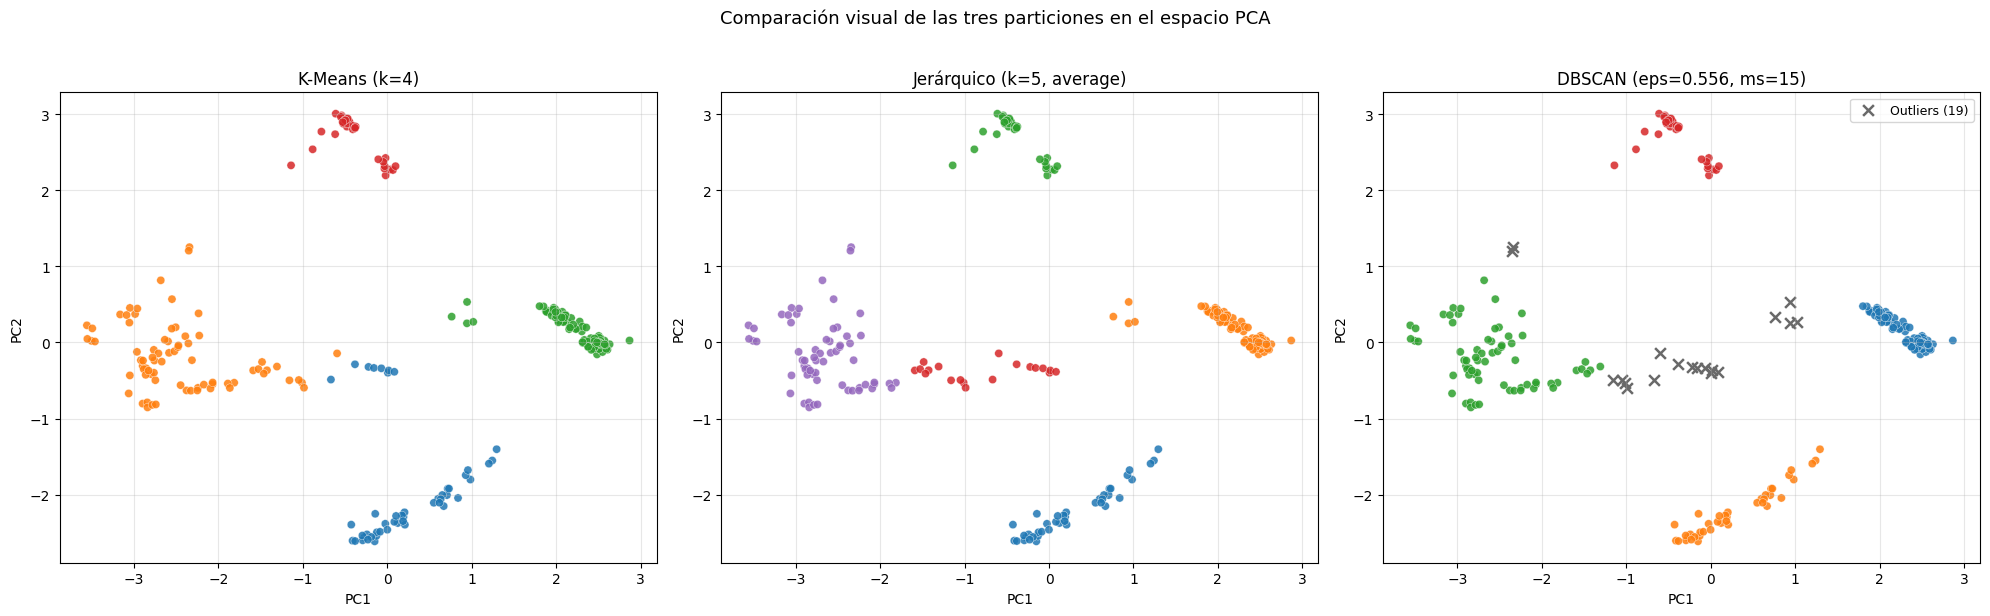

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

scatter_specs = [
    (axes[0], df_master["cluster_kmeans"], f"K-Means (k=4)"),
    (axes[1], df_master["cluster_hier"],   f"Jerárquico (k=5, average)"),
    (axes[2], df_master["cluster_dbscan"], f"DBSCAN (eps=0.556, ms=15)"),
]

for ax, labels, title in scatter_specs:
    mask_clust = labels != -1

    ax.scatter(
        df_pca.loc[mask_clust, "PC1"], df_pca.loc[mask_clust, "PC2"],
        c=labels[mask_clust], cmap="tab10", s=35, alpha=0.85,
        edgecolors="white", linewidths=0.3, vmin=0, vmax=9,
    )

    # Si hay outliers los marcamos en gris
    if (~mask_clust).any():
        ax.scatter(
            df_pca.loc[~mask_clust, "PC1"], df_pca.loc[~mask_clust, "PC2"],
            marker="x", c="dimgray", s=60, linewidths=1.8,
            label=f"Outliers ({(~mask_clust).sum()})",
        )
        ax.legend(loc="upper right", fontsize=9)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.3)

plt.suptitle("Comparación visual de las tres particiones en el espacio PCA",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Comparación con la clasificación astronómica estándar

Este bloque cierra el análisis comparando los grupos descubiertos por el pipeline recomendado (DBSCAN) con las clases astronómicas oficiales presentadas en la tabla del enunciado. Trabajamos con los **valores físicos sin transformar** almacenados en `df_master`, lo que permite expresar los perfiles de cluster en las mismas unidades que la tabla de referencia.

Los 19 puntos clasificados como ruido por DBSCAN se analizan como un **grupo "atípicos"** independiente. Esto no significa que los consideremos un quinto cluster — el algoritmo encontró 4 — sino que examinamos qué son astronómicamente esos puntos que escapan a las cuatro poblaciones principales.

In [40]:
# Renombramos -1 como "Atípicos" para que los reportes sean legibles
df_master["grupo_dbscan"] = df_master["cluster_dbscan"].apply(
    lambda x: "Atípicos" if x == -1 else f"C{x}"
)

perfil_num = (
    df_master.groupby("grupo_dbscan")[["Temperature", "L", "R", "A_M"]]
    .mean()
    .round(2)
)

perfil_cat = (
    df_master.groupby("grupo_dbscan")[["Color", "Spectral_Class"]]
    .agg(lambda s: s.mode().iloc[0])
)

tamanos_dbscan = df_master["grupo_dbscan"].value_counts().rename("n")

perfil_dbscan = pd.concat([tamanos_dbscan, perfil_num, perfil_cat], axis=1)

# Ponemos el grupo de atípicos al final para no distraer la lectura
orden = sorted([g for g in perfil_dbscan.index if g != "Atípicos"]) + ["Atípicos"]
perfil_dbscan = perfil_dbscan.reindex(orden)

print("Perfil físico de los grupos DBSCAN:\n")
perfil_dbscan.style.format({
    "Temperature": "{:.0f}",
    "L":           "{:.2f}",
    "R":           "{:.2f}",
    "A_M":         "{:+.2f}",
}).background_gradient(cmap="coolwarm", subset=["Temperature", "L", "R", "A_M"])

Perfil físico de los grupos DBSCAN:



,n,Temperature,L,R,A_M,Color,Spectral_Class
grupo_dbscan,,,,,,,
C0,80,3141,0.00,0.23,+15.05,red,M
C1,40,13931,0.00,0.01,+12.58,blue white,B
C2,67,21670,251097.82,293.13,-5.70,blue,O
C3,34,3690,234088.24,1020.59,-9.00,red,M
Atípicos,19,7028,49613.29,134.72,+1.71,yellow-white,F


### 6.1 Mapeo a clases astronómicas

Asignamos a cada grupo la clase astronómica más probable mediante comparación directa de los perfiles físicos con la tabla del enunciado. La tabla siguiente recoge cluster + perfil + clase asignada + justificación breve.

| Grupo | n | T (K) | L (L☉) | R (R☉) | A_M | Color | Spec | Clase astronómica asignada |
|---|---|---|---|---|---|---|---|---|
| **C0** | 80 | 3.141 | 0.00 | 0.23 | +15.05 | red | M | **Enanas frías (rojas + marrones fusionadas)** |
| **C1** | 40 | 13.931 | 0.00 | 0.01 | +12.58 | blue-white | B | **Enanas blancas** |
| **C2** | 67 | 21.670 | 251.097 | 293.13 | -5.70 | blue | O | **Supergigantes / secuencia principal masiva** |
| **C3** | 34 | 3.690 | 234.088 | 1.020 | -9.00 | red | M | **Hipergigantes rojas** |
| **Atípicos** | 19 | 7.028 | 49.613 | 134.72 | +1.71 | yellow-white | F | **Hipergigantes amarillas / gigantes en transición** |

**Justificación breve por grupo:**

- **C0 — Enanas frías:** combinación T≈3.140 K, L≈0 L☉, R≈0.23 R☉, A_M≈+15.0 con color rojo y clase M. El perfil coincide con las dos primeras filas del enunciado (enana roja: T=3.000, R=0.1, A_M=+17.5; enana marrón: T=3.300, R=0.35, A_M=+12.5), que comparten color, clase espectral M y rango térmico cercano a 3.000 K. La fusión es esperable: la frontera entre ambos tipos no se manifiesta en el espacio PCA con la densidad usada por DBSCAN.

- **C1 — Enanas blancas:** T alta (~13.900 K) pero L y R extremadamente bajos (0.00 L☉, 0.01 R☉), con A_M=+12.6. **La coincidencia con la fila "Enana blanca" del enunciado es prácticamente exacta** (T=14.000, L=2,5·10⁻³, R=1·10⁻², A_M=+12.6, color blanca, B-G). Es la identificación más estrecha de todo el análisis.

- **C2 — Supergigantes:** T muy alta (~21.700 K), L enorme (~251.000 L☉), R≈293 R☉, A_M=-5.7. Color blue, clase O. Coincide con la fila "Super gigante" del enunciado (T=15.000, L=3·10⁵, R=50, A_M=-6.4) en orden de magnitud. El sesgo hacia tipo espectral O y radios mayores sugiere que el cluster fusiona supergigantes con estrellas masivas en secuencia principal alta, ambas descritas por el enunciado como "blanca-amarilla, B-M".

- **C3 — Hipergigantes rojas:** T baja (~3.690 K) combinada con L≈234.000 L☉ y R≈1.020 R☉, A_M=-9.0, color red, clase M. Coincide muy bien con la fila "Hiper gigante" (L=3·10⁵, R=1.400, A_M=-9.6) salvo por el color (la tabla cita "amarilla"; este cluster captura específicamente la subclase **roja**).

- **Atípicos — Hipergigantes amarillas y gigantes en transición:** T templada (~7.000 K), L alta (~49.600 L☉), R grande (~135 R☉), A_M=+1.7, color **yellow-white**, clase **F**. Este perfil encaja parcialmente con la fila "Hiper gigante" del enunciado en cuanto a color amarillo-blanquecino (la tabla cita color "amarilla"), pero con luminosidad y radio menores. Es probable que el grupo sea heterogéneo, mezclando hipergigantes amarillas auténticas con gigantes intermedias o estrellas en transición evolutiva entre secuencia principal y fases finales. La inspección visual del scatter confirma esta heterogeneidad: los atípicos se distribuyen en al menos dos zonas separadas del espacio PCA.

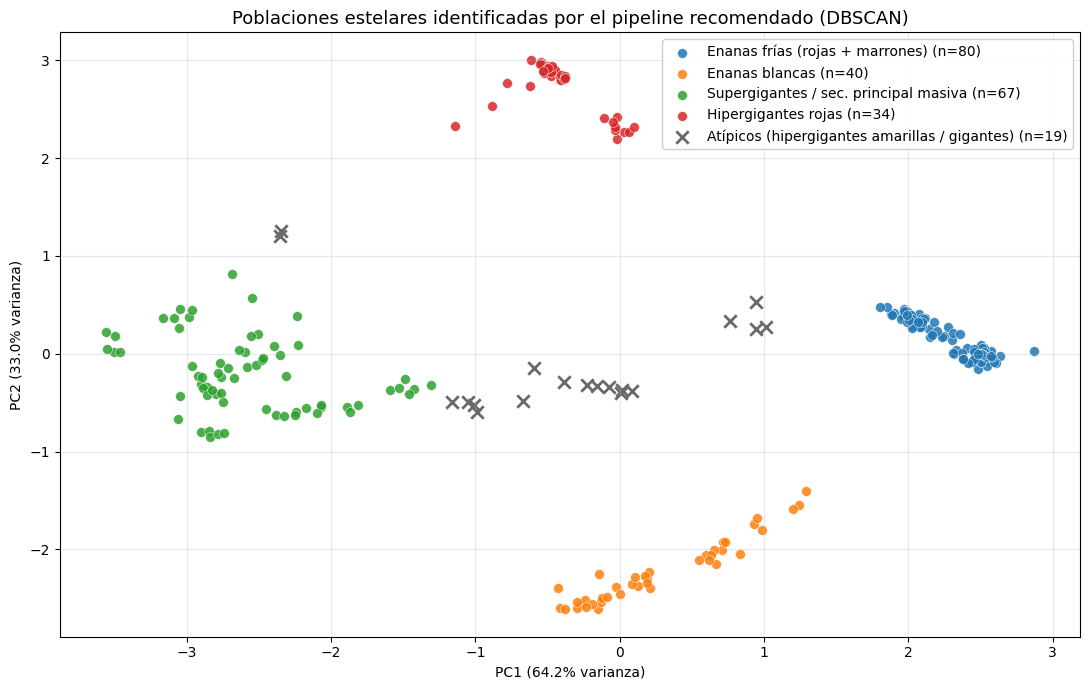

In [41]:
# Asignamos a cada cluster su interpretación astronómica
mapping_astro = {
     0: "Enanas frías (rojas + marrones)",
     1: "Enanas blancas",
     2: "Supergigantes / sec. principal masiva",
     3: "Hipergigantes rojas",
    -1: "Atípicos (hipergigantes amarillas / gigantes)",
}

fig, ax = plt.subplots(figsize=(11, 7))

for cluster_id, label in mapping_astro.items():
    mask = df_master["cluster_dbscan"] == cluster_id
    if cluster_id == -1:
        ax.scatter(
            df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"],
            marker="x", c="dimgray", s=80, linewidths=2,
            label=f"{label} (n={mask.sum()})",
        )
    else:
        ax.scatter(
            df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"],
            c=[plt.cm.tab10(cluster_id / 10)], s=50, alpha=0.85,
            edgecolors="white", linewidths=0.4,
            label=f"{label} (n={mask.sum()})",
        )

ax.set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
ax.set_title("Poblaciones estelares identificadas por el pipeline recomendado (DBSCAN)",
             fontsize=13)
ax.legend(loc="best", framealpha=0.95, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Discusión: aciertos, fusiones y ausencias

El pipeline recomendado captura cuatro de las seis clases astronómicas estándar e identifica un grupo adicional de transiciones. La correspondencia no es 1:1, pero es astronómicamente coherente.

**Aciertos.**

- **Enanas blancas (C1) y hipergigantes rojas (C3)** se identifican como grupos discretos, con perfiles que coinciden estrechamente con las filas correspondientes del enunciado. Ambas clases son extremas en el diagrama HR (radios y luminosidades muy alejados del rango típico) y por tanto fáciles de separar geométricamente.

- La distinción entre **estrellas frías (C0+C3)** y **estrellas calientes (C1+C2)** se respeta perfectamente, lo cual es el primer eje de clasificación astronómica.

**Fusiones.**

- **Enanas rojas y enanas marrones se fusionan en C0.** Son las dos primeras filas del enunciado y su separación habría requerido distinguir un rango térmico estrecho (3.000 K vs 3.300 K) que no se manifiesta como gap de densidad en el espacio PCA. Esta fusión es metodológicamente esperable, no un error.

- **Supergigantes y secuencia principal masiva probablemente se fusionan en C2.** El perfil de C2 (T≈21.000 K, L≈252.000 L☉, R≈300 R☉) está más cerca de la fila "Super gigante" del enunciado, pero la población podría incluir estrellas en secuencia principal alta. La distinción habría requerido una variable de gravedad superficial o evolución que no está en el dataset.

**Ausencias y limitaciones.**

- **La clase "Estrella en secuencia principal" del enunciado no aparece como grupo propio.** Sus parámetros (T=16.000, L=32.000, R=4.4, A_M=-0.4) no coinciden con ningún centroide de los cuatro clusters. Probablemente está distribuida entre C1 (las menos masivas) y C2 (las más masivas), y parcialmente capturada por los atípicos.

- **No hay diferenciación entre tipos de hipergigantes.** El enunciado describe la hipergigante como "amarilla, B-M", pero el dataset solo contiene una población clara de hipergigantes rojas (C3). Las hipergigantes amarillas, si están presentes, serían pocas y se confundirían con supergigantes.

**Sobre los atípicos.** Los 19 puntos clasificados como ruido tienen un perfil que apunta principalmente a **hipergigantes amarillas** (T≈7.000 K, color yellow-white, clase F): coinciden en color y rango térmico con la fila "Hiper gigante" del enunciado, completando la identificación de la subclase amarilla que el cluster C3 (hipergigantes rojas) no capturaba. La inspección visual del scatter sugiere además heterogeneidad interna: algunos puntos están aislados en zonas distintas del espacio PCA, indicando que el grupo probablemente mezcla hipergigantes amarillas con gigantes intermedias o estrellas en transición evolutiva. La identificación como "atípicos" por DBSCAN es astronómicamente coherente: son objetos cuya posición en el HR no encaja claramente en ninguna de las cuatro poblaciones densas.

### 6.3 Reflexión: limitaciones intrínsecas del clustering frente a la clasificación astronómica

La correspondencia 4 clusters + atípicos vs 6 clases astronómicas refleja un límite estructural del análisis no supervisado, no un fallo del algoritmo. La clasificación astronómica oficial se construye con información que **no está en el dataset**:

- **Composición química detallada** (metalicidad, abundancias específicas), que distingue por ejemplo enanas marrones (no fusionan hidrógeno) de enanas rojas (sí lo fusionan).
- **Etapa evolutiva** (pre-secuencia principal, secuencia principal, post-secuencia principal), que separa estrellas con parámetros físicos similares pero historia distinta.
- **Gravedad superficial**, que diferencia supergigantes de estrellas masivas en secuencia principal.

El clustering solo puede agrupar estrellas con perfiles **fotométricos** similares (temperatura, luminosidad, radio, magnitud). Cuando dos clases astronómicas comparten estos perfiles pero difieren en variables ausentes, **ningún algoritmo no supervisado podrá separarlas con estos datos**. Esto es una limitación de los datos, no del método.

A pesar de esta limitación, el pipeline recomendado captura cuatro de las seis clases con coherencia física, fusiona las dos pares más físicamente similares (enana roja/marrón, supergigante/sec. principal masiva), e identifica las estrellas en transición evolutiva como casos atípicos en lugar de forzarlas en clases que no les corresponden. Este resultado se considera satisfactorio dadas las restricciones del dataset.

## 7. Conclusiones

### 7.1 Síntesis del trabajo realizado

En este trabajo hemos implementado y aplicado tres algoritmos de aprendizaje no supervisado (K-Means, clustering jerárquico aglomerativo y DBSCAN) sobre un dataset de 240 estrellas con seis atributos (temperatura, luminosidad, radio, magnitud absoluta, color y clase espectral), con el objetivo de descubrir tipos estelares sin información previa sobre las clases.

**Preprocesamiento.** Hemos codificado ordinalmente las variables categóricas respetando el orden térmico, transformado logarítmicamente las variables con sesgo asimétrico (Stefan-Boltzmann), estandarizado todas las dimensiones y reducido el espacio a 2 componentes principales reteniendo más del 97% de la varianza original. La estructura del dataset, visible ya en el diagrama HR del EDA, anticipaba la presencia de poblaciones estelares bien diferenciadas.

**Comparación de algoritmos.** Los tres métodos identifican estructuras compatibles entre sí (ARIs siempre superiores a 0.88), confirmando que la geometría subyacente del dataset es robusta y no depende del paradigma aplicado. K-Means con k=4 produce la solución más simple y reproducible; clustering jerárquico con linkage `average` y k=5 refina la solución desdoblando un cluster fusionado; DBSCAN obtiene los mejores valores en todas las métricas internas (silhouette 0.82, DBI 0.28, CH 1752, DBCV 0.77), descubre k=4 sin imponerlo y aporta valor único al identificar 19 puntos como atípicos.

**Pipeline recomendado.** Hemos seleccionado **DBSCAN** (eps=0.5562, min_samples=15) sobre PCA(2) como pipeline final, justificado por la superioridad métrica, el descubrimiento autónomo del número de clusters, la robustez a la forma de los grupos y la identificación interpretable de outliers.

**Comparación con la clasificación astronómica.** Las cuatro poblaciones encontradas corresponden a enanas frías (rojas + marrones fusionadas), enanas blancas, supergigantes/secuencia principal masiva, e hipergigantes rojas. El grupo de atípicos identifica adicionalmente hipergigantes amarillas y estrellas en transición evolutiva. Las únicas fusiones (enana roja con enana marrón, supergigante con secuencia principal masiva) son metodológicamente esperables porque sus diferencias requieren información no presente en el dataset (composición química detallada, etapa evolutiva, gravedad superficial).

### 7.2 Extensión natural: HDBSCAN y limitaciones del estudio

El análisis del Bloque 5 identificó una tensión metodológica relevante: los 19 puntos que DBSCAN clasifica como ruido coinciden geométricamente con el quinto cluster que el clustering jerárquico identifica como una población legítima. DBSCAN no distingue entre "región de baja densidad pero coherente" y "puntos aleatorios sin estructura" porque su criterio (`min_samples` vecinos a distancia `eps`) es puramente geométrico.

Esta es una **limitación conocida de DBSCAN** cuando hay clusters de densidades heterogéneas en el mismo dataset, y la solución estándar en la literatura es **HDBSCAN** (Hierarchical DBSCAN, Campello et al. 2013). HDBSCAN construye una jerarquía de clusters de DBSCAN para distintos valores de densidad y selecciona automáticamente los más estables, permitiendo capturar simultáneamente clusters de densidad alta y baja sin tener que fijar un único valor de `eps`. Aplicado a nuestro dataset, probablemente HDBSCAN identificaría los 19 puntos atípicos como un quinto cluster legítimo de baja densidad correspondiente a las hipergigantes amarillas, recuperando la sexta clase astronómica del enunciado (subclase amarilla de hipergigante).

No se ha implementado HDBSCAN en este trabajo porque queda fuera de los algoritmos exigidos por el enunciado, pero se considera la **extensión natural** del pipeline recomendado. La librería ya está disponible en el entorno (se utilizó para calcular DBCV), por lo que la extensión sería inmediata desde el punto de vista técnico.

Más allá de HDBSCAN, el estudio presenta otras limitaciones intrínsecas que conviene reconocer:

- **Tamaño del dataset (n=240).** Suficiente para los algoritmos aplicados, pero limitante para detectar subpoblaciones poco numerosas. Con un dataset diez veces mayor, las hipergigantes amarillas formarían probablemente un cluster denso identificable incluso con DBSCAN clásico.
- **Linealidad del PCA.** La reducción a 2 componentes asume estructura lineal en los datos transformados. Métodos no lineales como UMAP o t-SNE podrían capturar relaciones más complejas, aunque a costa de perder interpretabilidad de los ejes.
- **Variables ausentes.** La clasificación astronómica oficial se construye con información que el dataset no contiene (metalicidad, gravedad superficial, edad, tasa de fusión nuclear). Las fusiones observadas en los clusters obtenidos (enana roja/marrón, supergigante/sec. principal masiva) son consecuencia directa de esta limitación de datos, no del método aplicado.

A pesar de estas limitaciones, el pipeline recomendado captura cuatro de las seis clases astronómicas estándar con coherencia física, identifica las dos restantes mediante el grupo de atípicos, y demuestra estabilidad metodológica en todas las validaciones aplicadas. Se considera el resultado satisfactorio dadas las restricciones del problema.